Connected to Python 3.11.8

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

cps = pd.read_csv("https://raw.githubusercontent.com/JSC370/JSC370-2026/main/data/cps_clean.csv")
cps = cps[cps['YEAR'].isin([2024, 2025])]
print(f"Dataset size (2024-2025): {cps.shape[0]} rows")
cps.head()

Dataset size (2024-2025): 98270 rows


,AGE,female,married,educ_cat,faminc_cat,metro_binary,race_cat,us_citizen,has_children,insured,OCC,IND,INCWAGE,FIRMSIZE,NCHILD,YEAR,STATEFIP,worker_cat
231802,63,0,1,2,3,0,White,1,1,1,6130,270,61729,2,1,2024,23,Self-employed
231803,57,0,1,2,2,0,White,1,1,1,4220,4972,43000,9,1,2024,23,Private for-profit
231804,57,1,1,2,2,0,White,1,1,1,9005,6380,25000,9,1,2024,23,Part-time
231805,23,0,0,2,2,0,White,1,0,1,9620,6170,20000,5,0,2024,23,Private for-profit
231806,58,0,0,3,1,0,White,1,0,1,6355,1870,80000,8,0,2024,23,Private for-profit


In [ ]:
# feature engineering -> turning race cat into dummy variables one hot encoded.
cps_encoded = pd.get_dummies(cps, columns=['race_cat'], drop_first=True)

feature_cols = ['AGE', 'female', 'married', 'educ_cat', 'faminc_cat',
                'metro_binary', 'us_citizen', 'has_children', 'insured',
                'FIRMSIZE', 'NCHILD',
                'race_cat_Black', 'race_cat_Other', 'race_cat_White']

cps_encoded.head()

,AGE,female,married,educ_cat,faminc_cat,metro_binary,us_citizen,has_children,insured,OCC,IND,INCWAGE,FIRMSIZE,NCHILD,YEAR,STATEFIP,worker_cat,race_cat_Black,race_cat_Other,race_cat_White
231802,63,0,1,2,3,0,1,1,1,6130,270,61729,2,1,2024,23,Self-employed,False,False,True
231803,57,0,1,2,2,0,1,1,1,4220,4972,43000,9,1,2024,23,Private for-profit,False,False,True
231804,57,1,1,2,2,0,1,1,1,9005,6380,25000,9,1,2024,23,Part-time,False,False,True
231805,23,0,0,2,2,0,1,0,1,9620,6170,20000,5,0,2024,23,Private for-profit,False,False,True
231806,58,0,0,3,1,0,1,0,1,6355,1870,80000,8,0,2024,23,Private for-profit,False,False,True


In [ ]:
# YOUR CODE HERE
X_class = cps_encoded[feature_cols]
y_class = cps_encoded['worker_cat']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size = 0.3, train_size = 0.7, random_state = 65)

print(f"Training set size: {}")
print(f"Testing set size: {}")
print(f"\nCount of each worker_cat category in training set:")
print()
print(f"\nProportions:")
print()

SyntaxError: f-string: empty expression not allowed (<ipython-input-3-77b5d0a5279c>, line 7)

In [ ]:
# YOUR CODE HERE
X_class = cps_encoded[feature_cols]
y_class = cps_encoded['worker_cat']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size = 0.3, train_size = 0.7, random_state = 65)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nCount of each worker_cat category in training set:")
print(X_train.value_counts())
print(f"\nProportions:")
print(X_train.value_counts(normalized=True))

Training set size: 68789
Testing set size: 29481

Count of each worker_cat category in training set:
AGE  female  married  educ_cat  faminc_cat  metro_binary  us_citizen  has_children  insured  FIRMSIZE  NCHILD  race_cat_Black  race_cat_Other  race_cat_White
18   0       0        1         3           1             1           0             1        9         0       False           False           True              40
17   1       0        1         3           1             1           0             1        9         0       False           False           True              38
     0       0        1         3           1             1           0             1        9         0       False           False           True              36
25   1       0        4         3           1             1           0             1        9         0       False           False           True              36
20   1       0        3         3           1             1           0             1

TypeError: DataFrame.value_counts() got an unexpected keyword argument 'normalized'

In [ ]:
# YOUR CODE HERE
X_class = cps_encoded[feature_cols]
y_class = cps_encoded['worker_cat']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size = 0.3, train_size = 0.7, random_state = 65)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nCount of each worker_cat category in training set:")
print(X_train.value_counts())
print(f"\nProportions:")
print(X_train.value_counts(normalize=True))

Training set size: 68789
Testing set size: 29481

Count of each worker_cat category in training set:
AGE  female  married  educ_cat  faminc_cat  metro_binary  us_citizen  has_children  insured  FIRMSIZE  NCHILD  race_cat_Black  race_cat_Other  race_cat_White
18   0       0        1         3           1             1           0             1        9         0       False           False           True              40
17   1       0        1         3           1             1           0             1        9         0       False           False           True              38
     0       0        1         3           1             1           0             1        9         0       False           False           True              36
25   1       0        4         3           1             1           0             1        9         0       False           False           True              36
20   1       0        3         3           1             1           0             1

In [ ]:
# YOUR CODE HERE
X_class = cps_encoded[feature_cols]
y_class = cps_encoded['worker_cat']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size = 0.3, train_size = 0.7, random_state = 65)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nCount of each worker_cat category in training set:")
print(y_train.value_counts())
print(f"\nProportions:")
print(y_train.value_counts(normalize=True))

Training set size: 68789
Testing set size: 29481

Count of each worker_cat category in training set:
worker_cat
Private for-profit    39993
Part-time             12892
Government             8045
Self-employed          4733
Unemployed             3126
Name: count, dtype: int64

Proportions:
worker_cat
Private for-profit    0.581387
Part-time             0.187414
Government            0.116952
Self-employed         0.068805
Unemployed            0.045443
Name: proportion, dtype: float64


Number of leaves in full tree: 5831
Depth of full tree: 34


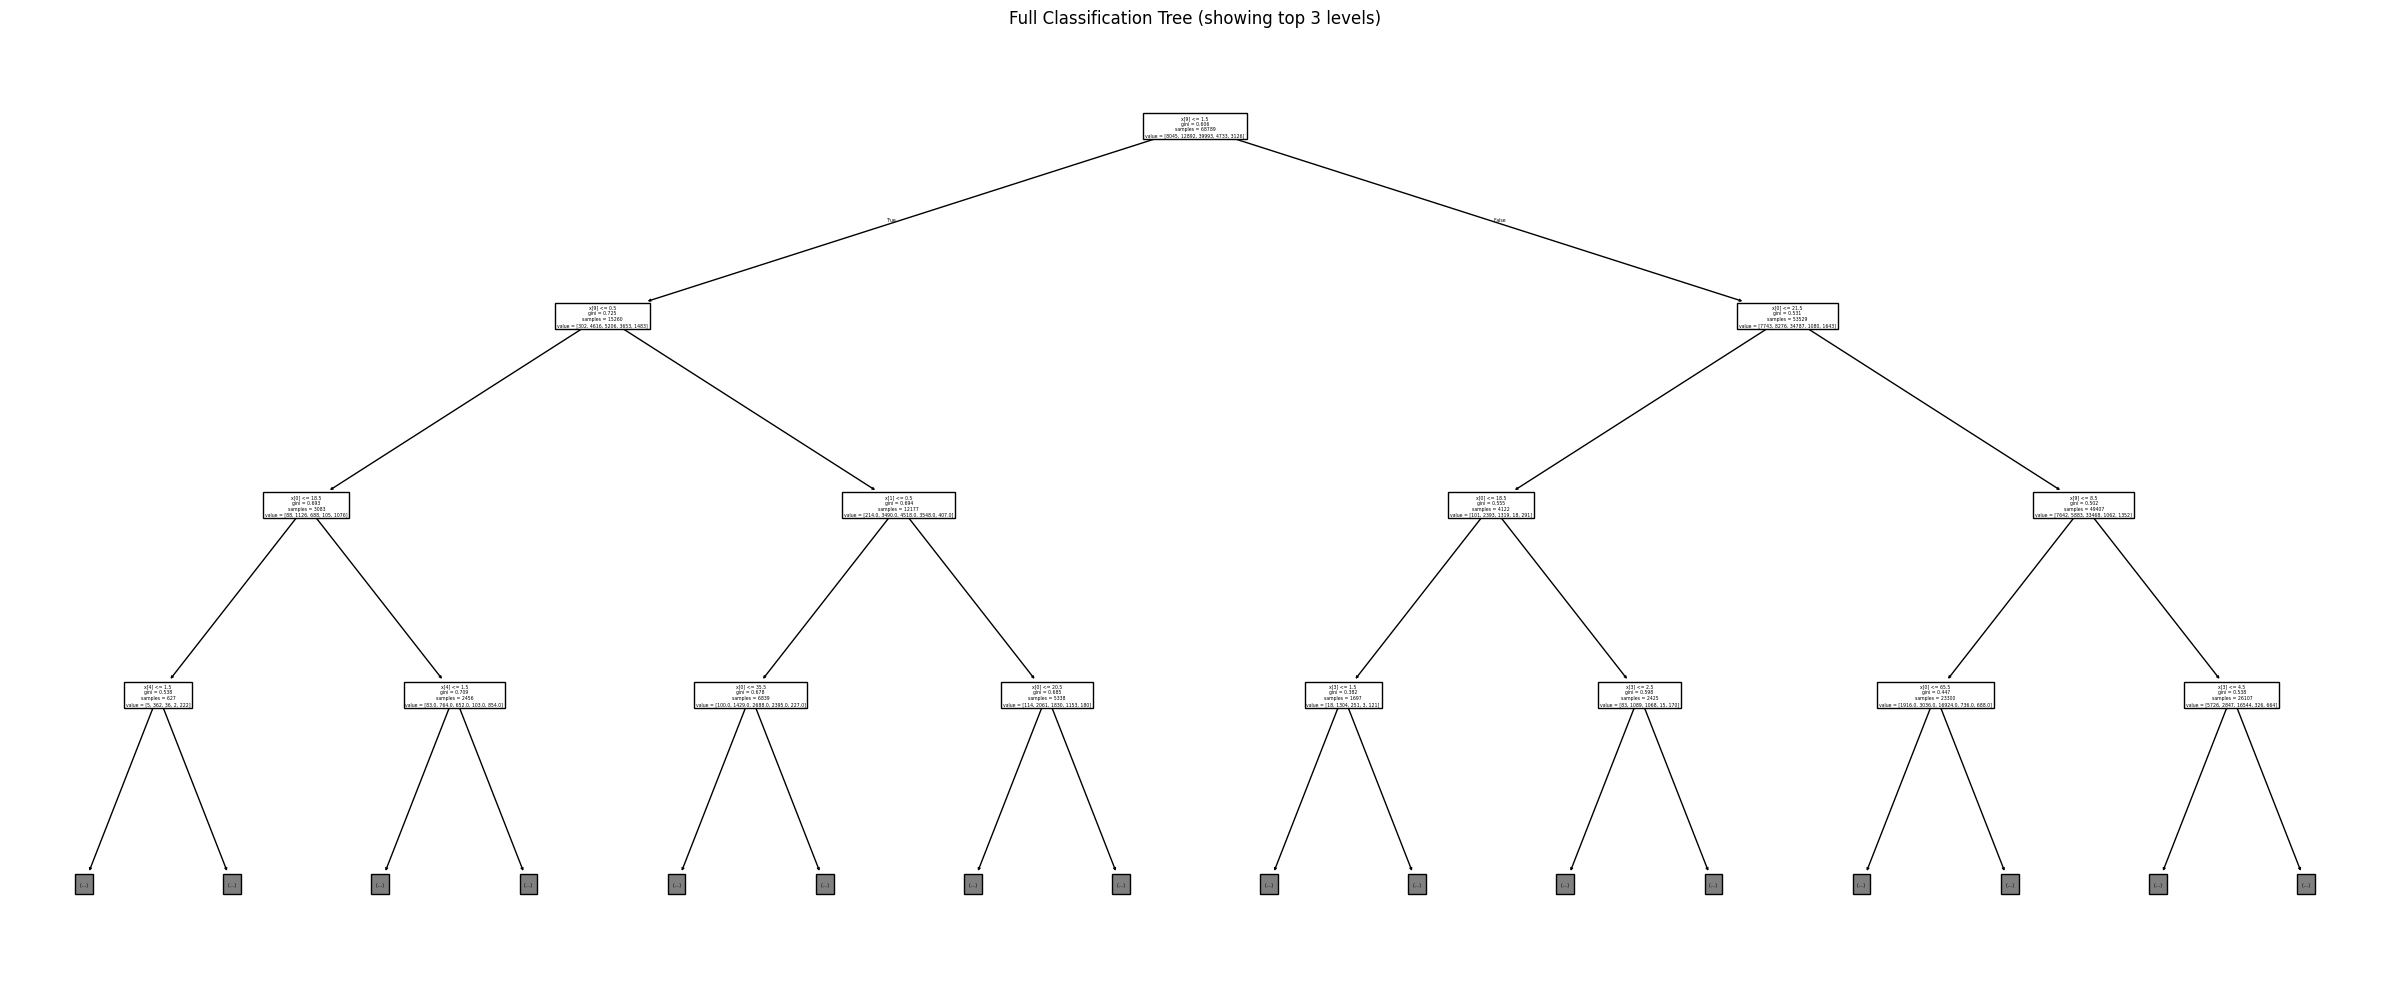

In [ ]:
# YOUR CODE HERE

# sort in alphabetical order for conveience
class_labels = sorted(y_class.unique())

# initalize model
full_tree_c = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
# pass in data to fit the model
full_tree_c.fit(X_train, y_train)

print(f"Number of leaves in full tree: {full_tree_c.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_c.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_c, max_depth=3)
plt.title("Full Classification Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

Number of leaves in full tree: 5831
Depth of full tree: 34


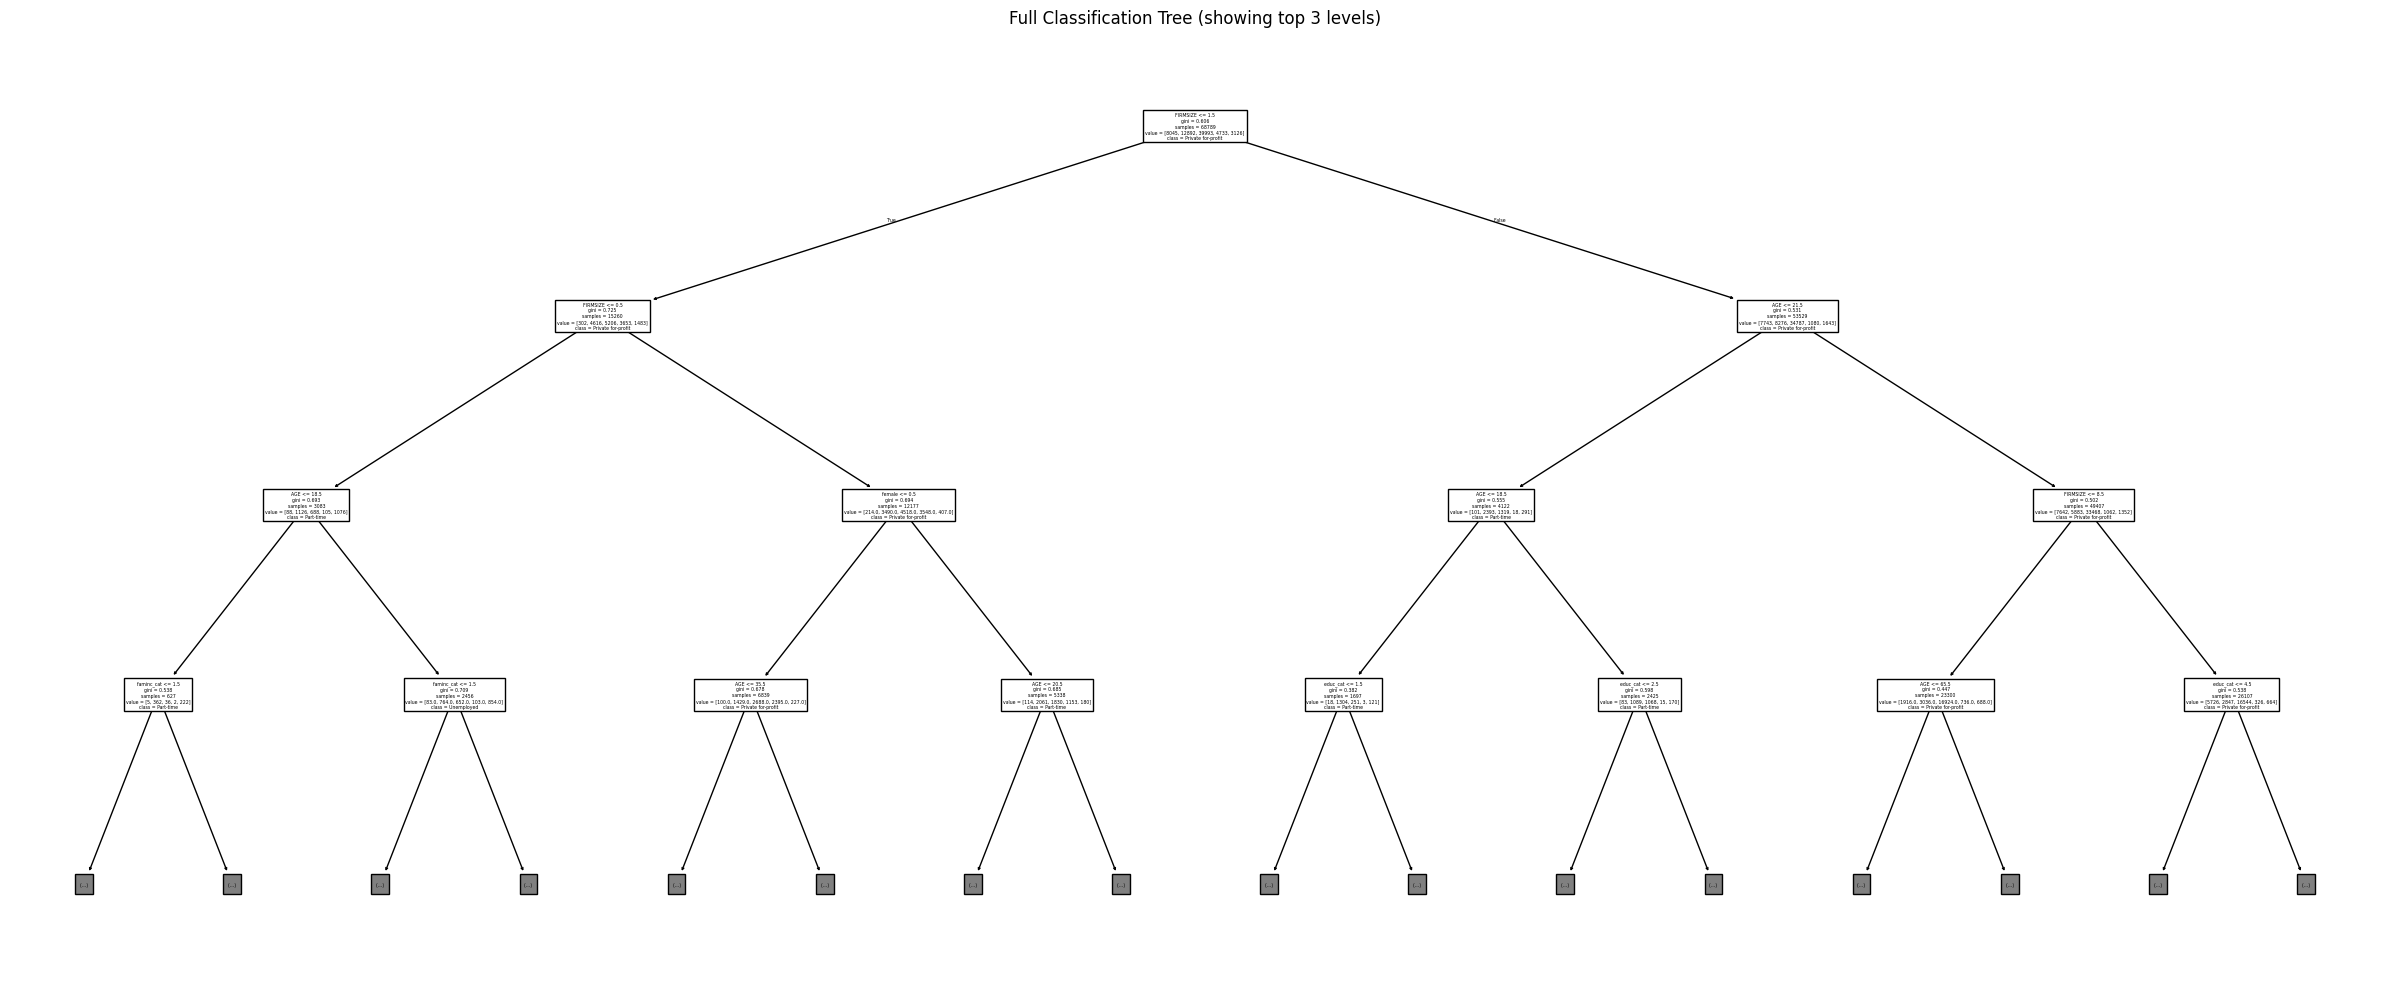

In [ ]:
# YOUR CODE HERE

# sort in alphabetical order for conveience
class_labels = sorted(y_class.unique())

# initalize model
full_tree_c = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
# pass in data to fit the model
full_tree_c.fit(X_train, y_train)

print(f"Number of leaves in full tree: {full_tree_c.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_c.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_c, max_depth=3, feature_names = feature_cols, class_names=class_labels)
plt.title("Full Classification Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

In [ ]:
# YOUR CODE HERE

# sort in alphabetical order for conveience
class_labels = sorted(y_class.unique())

# initalize model
full_tree_c = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
# pass in data to fit the model
full_tree_c.fit(X_train, y_train)

print(f"Number of leaves in full tree: {full_tree_c.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_c.get_depth()}")

plt.figure(figsize=(24, 10))

# class name is the decision for each leaf 
plot_tree(full_tree_c, max_depth=3, feature_names = feature_cols, class_names=class_labels, font_size = 7)
plt.title("Full Classification Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

Number of leaves in full tree: 5831
Depth of full tree: 34


TypeError: got an unexpected keyword argument 'font_size'

<Figure size 2400x1000 with 0 Axes>

Number of leaves in full tree: 5831
Depth of full tree: 34


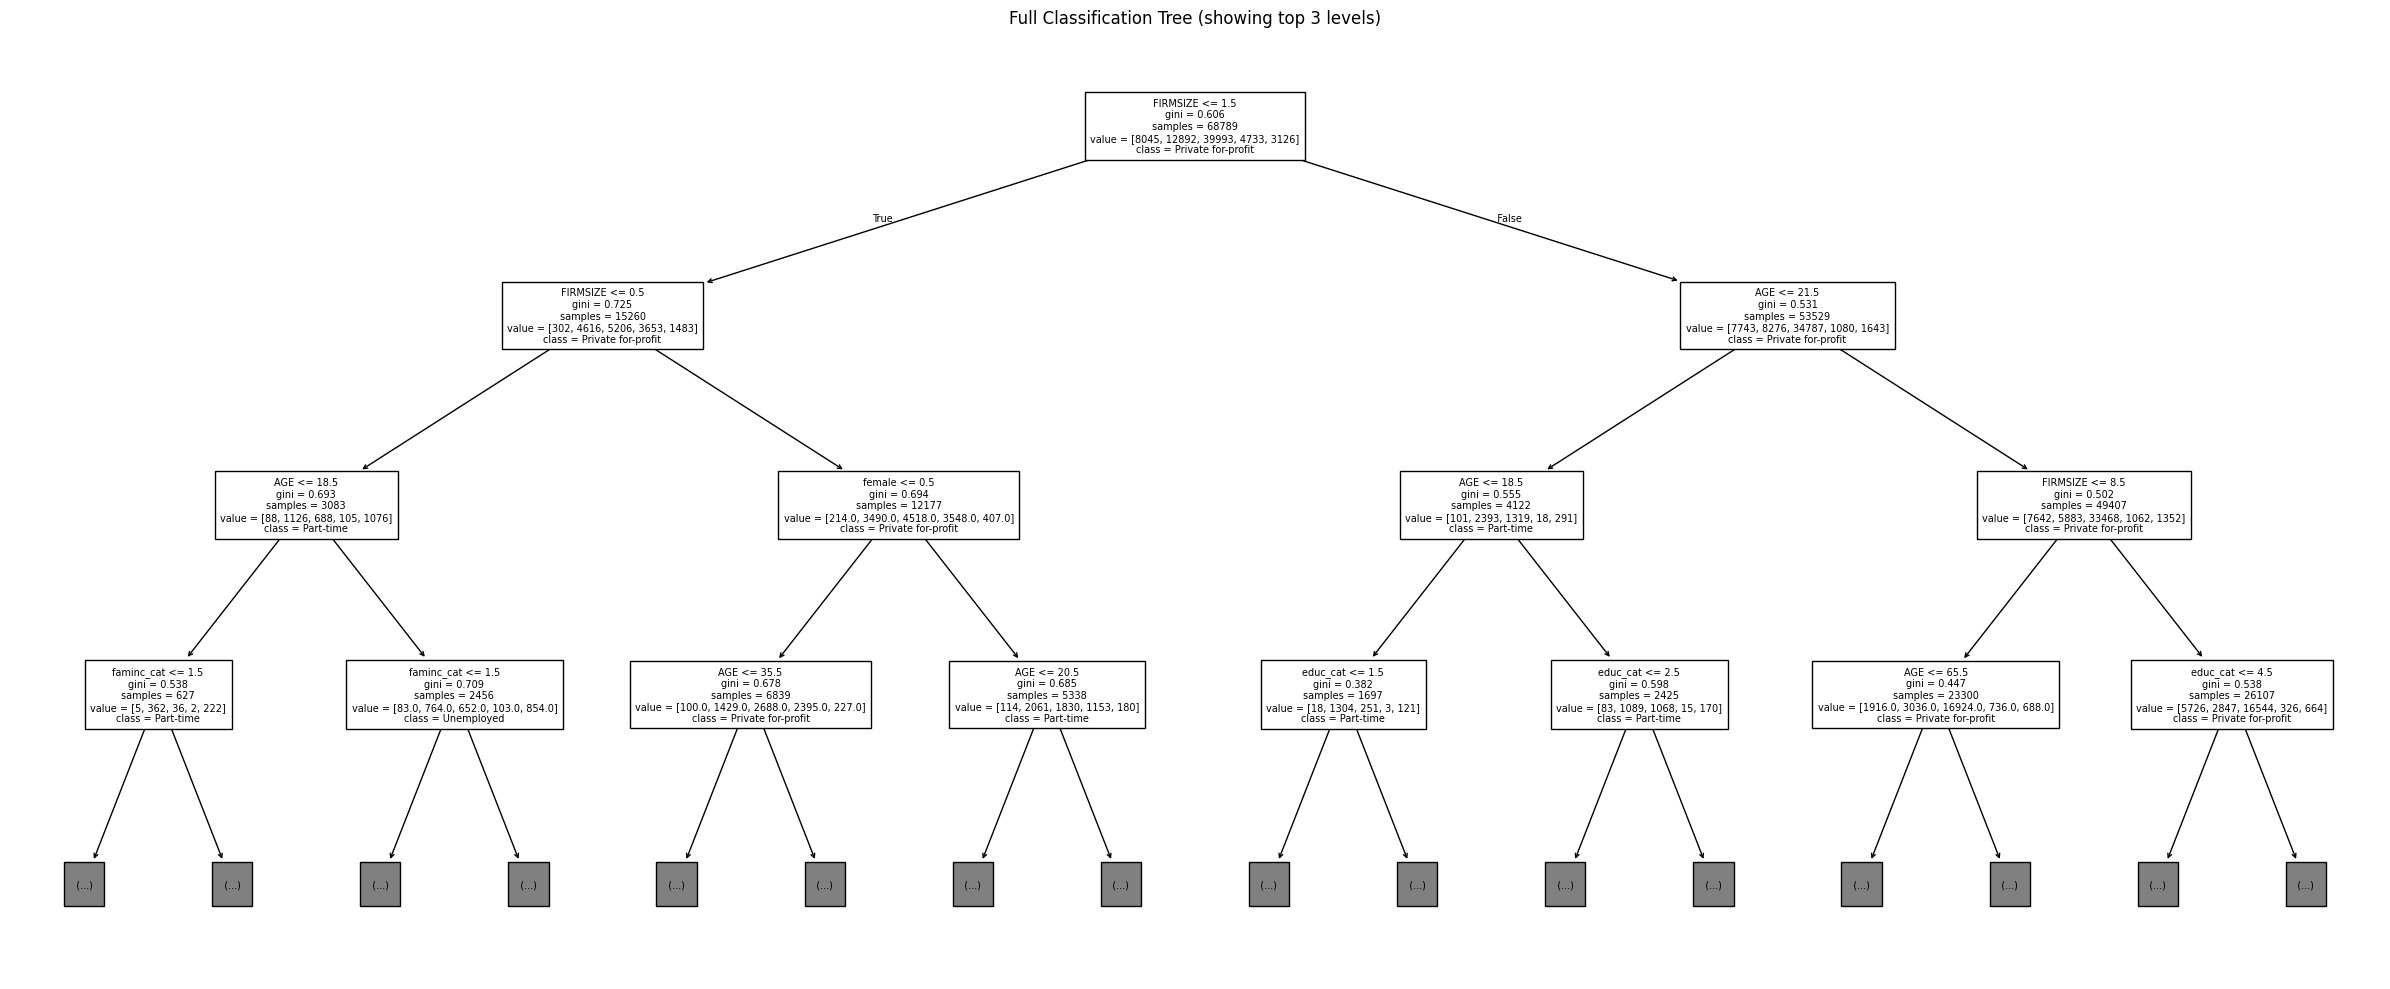

In [ ]:
# YOUR CODE HERE

# sort in alphabetical order for conveience
class_labels = sorted(y_class.unique())

# initalize model
full_tree_c = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
# pass in data to fit the model
full_tree_c.fit(X_train, y_train)

print(f"Number of leaves in full tree: {full_tree_c.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_c.get_depth()}")

plt.figure(figsize=(24, 10))

# class name is the decision for each leaf 
plot_tree(full_tree_c, max_depth=3, feature_names = feature_cols, class_names=class_labels, fontsize=7)
plt.title("Full Classification Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(n.log10(ccp_alphas_pos.min()), n.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
    tree.fit(X_train, y_train)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

NameError: name 'n' is not defined

In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(np.log10(ccp_alphas_pos.min()), n.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
    tree.fit(X_train, y_train)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

NameError: name 'n' is not defined

In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(np.log10(ccp_alphas_pos.min()), np.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
    tree.fit(X_train, y_train)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

       ccp_alpha  n_leaves
0   3.607248e-08      5831
1   6.382565e-08      5831
2   1.129314e-07      5831
3   1.998176e-07      5831
4   3.535519e-07      5831
5   6.255650e-07      5831
6   1.106858e-06      5831
7   1.958443e-06      5831
8   3.465216e-06      5831
9   6.131258e-06      5831
10  1.084848e-05      5831
11  1.919500e-05      5831
12  3.396311e-05      5831
13  6.009340e-05      5831
14  1.063276e-04      5831
15  1.881332e-04      5831
16  3.328777e-04      5831
17  5.889846e-04      5831
18  1.042133e-03      5831
19  1.843922e-03      5831
20  3.262585e-03      5831
21  5.772729e-03      5831
22  1.021411e-02      5831
23  1.807256e-02      5831
24  3.197710e-02      5831


In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(np.log10(ccp_alphas_pos.min()), np.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65)
    tree.fit(X_train, y_train, sample_weight = alpha)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

       ccp_alpha  n_leaves
0   3.607248e-08      5833
1   6.382565e-08      5834
2   1.129314e-07      5836
3   1.998176e-07      5838
4   3.535519e-07      5834
5   6.255650e-07      5844
6   1.106858e-06      5839
7   1.958443e-06      5851
8   3.465216e-06      5836
9   6.131258e-06      5839
10  1.084848e-05      5835
11  1.919500e-05      5834
12  3.396311e-05      5842
13  6.009340e-05      5833
14  1.063276e-04      5833
15  1.881332e-04      5833
16  3.328777e-04      5831
17  5.889846e-04      5835
18  1.042133e-03      5835
19  1.843922e-03      5832
20  3.262585e-03      5843
21  5.772729e-03      5834
22  1.021411e-02      5832
23  1.807256e-02      5836
24  3.197710e-02      5844


In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(np.log10(ccp_alphas_pos.min()), np.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

       ccp_alpha  n_leaves
0   3.607248e-08      5829
1   6.382565e-08      5827
2   1.129314e-07      5826
3   1.998176e-07      5822
4   3.535519e-07      5816
5   6.255650e-07      5802
6   1.106858e-06      5745
7   1.958443e-06      5623
8   3.465216e-06      5349
9   6.131258e-06      4736
10  1.084848e-05      3441
11  1.919500e-05      1539
12  3.396311e-05       432
13  6.009340e-05       140
14  1.063276e-04        86
15  1.881332e-04        43
16  3.328777e-04        31
17  5.889846e-04        21
18  1.042133e-03        15
19  1.843922e-03         9
20  3.262585e-03         5
21  5.772729e-03         4
22  1.021411e-02         3
23  1.807256e-02         3
24  3.197710e-02         1


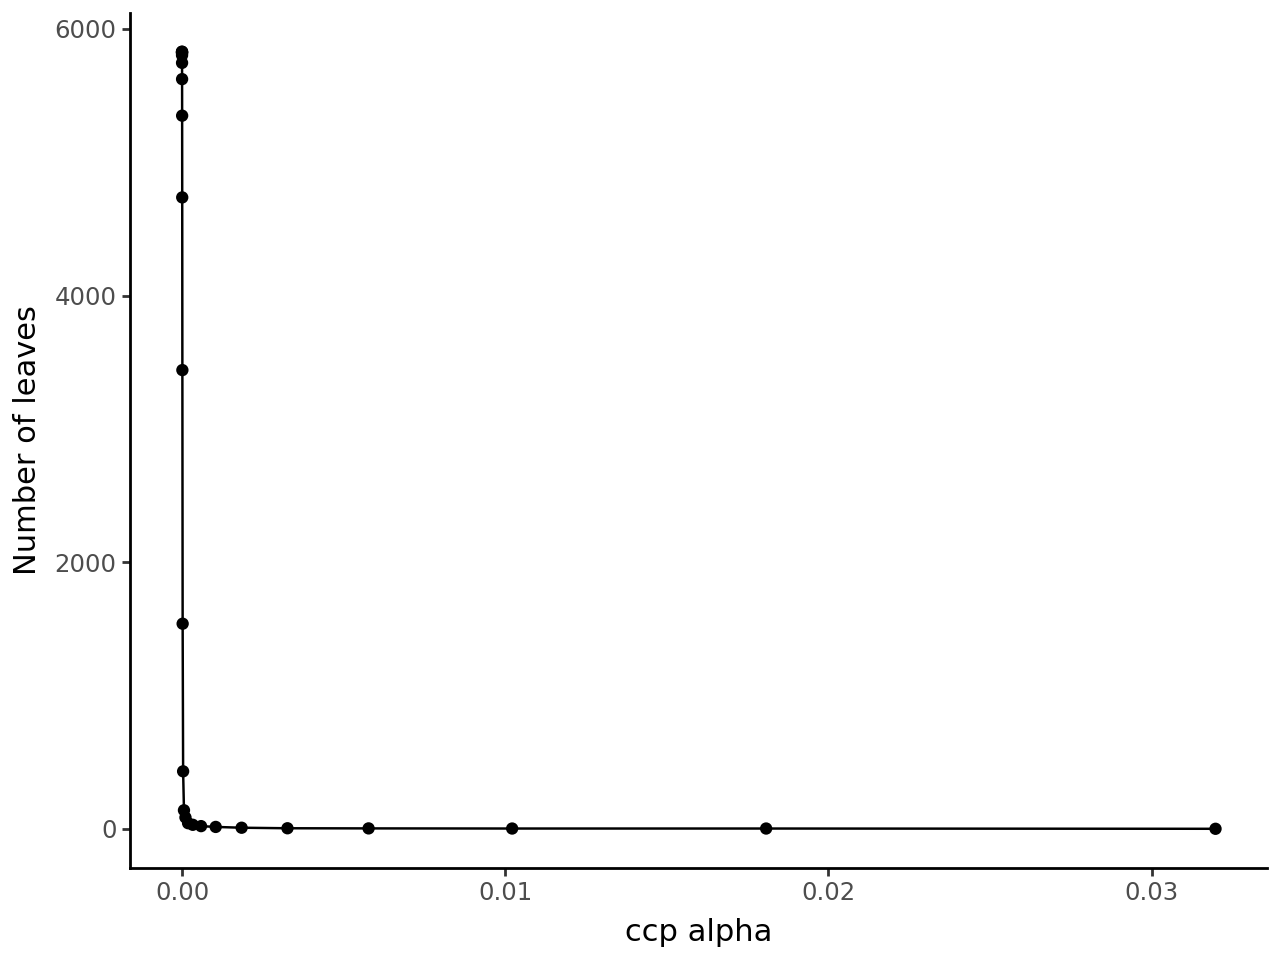

In [ ]:
# Plot number of leaves vs ccp_alpha
(
  ggplot(ccp_df, aes(x= 'ccp_alpha', y = 'n_leaves')) +
  geom_line() +
  geom_point() +
  labs(x = 'ccp alpha', y = 'Number of leaves') +
  theme_classic()
)

In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(np.log10(ccp_alphas_pos.min()), np.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': 10 ** log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

    ccp_alpha  n_leaves
0    1.000000      5829
1    1.000000      5827
2    1.000000      5826
3    1.000000      5822
4    1.000001      5816
5    1.000001      5802
6    1.000003      5745
7    1.000005      5623
8    1.000008      5349
9    1.000014      4736
10   1.000025      3441
11   1.000044      1539
12   1.000078       432
13   1.000138       140
14   1.000245        86
15   1.000433        43
16   1.000767        31
17   1.001357        21
18   1.002402        15
19   1.004255         9
20   1.007541         5
21   1.013381         4
22   1.023798         3
23   1.042492         3
24   1.076408         1


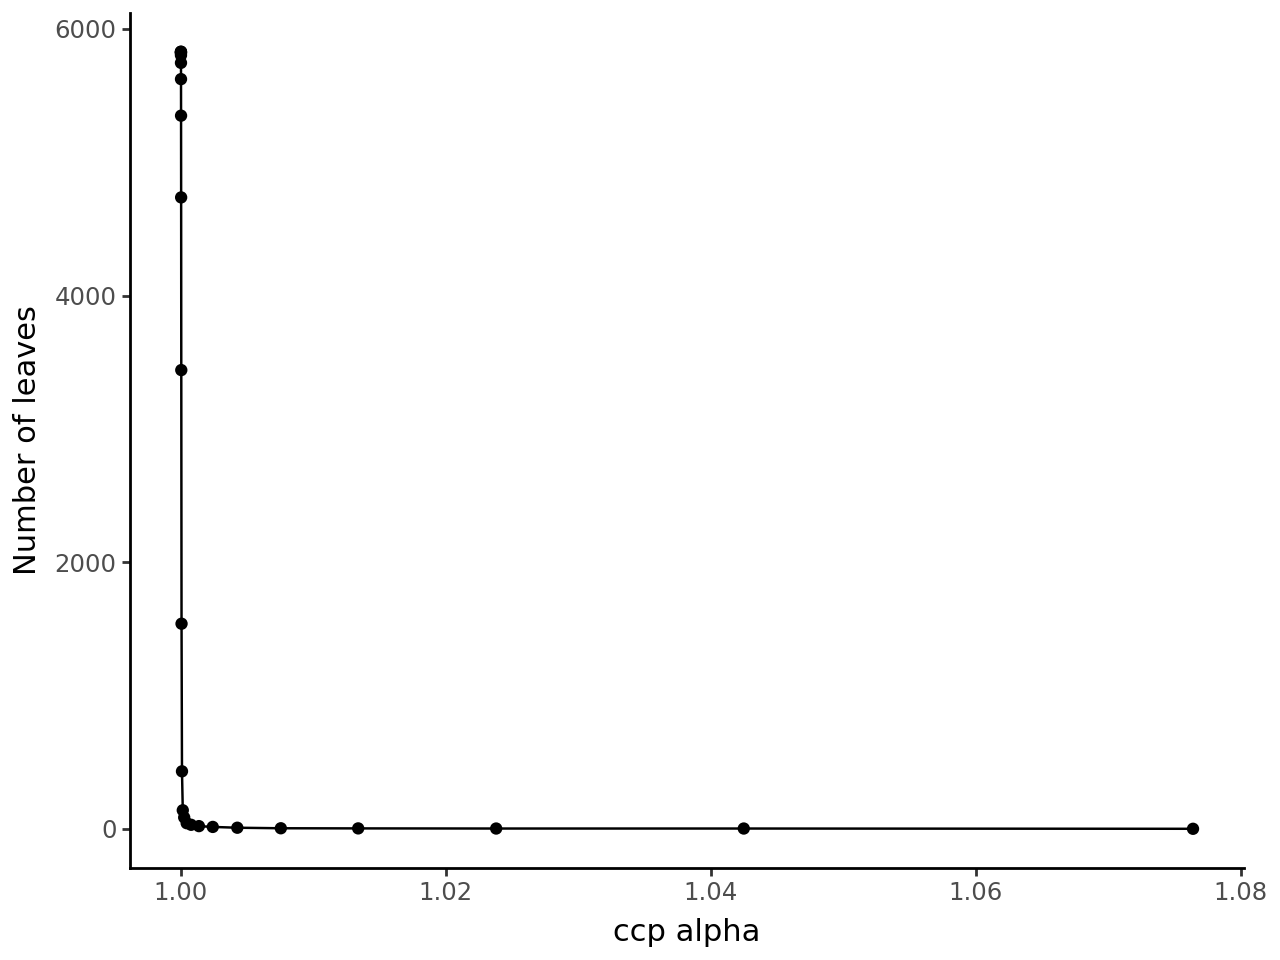

In [ ]:
# Plot number of leaves vs ccp_alpha
(
  ggplot(ccp_df, aes(x= 'ccp_alpha', y = 'n_leaves')) +
  geom_line() +
  geom_point() +
  labs(x = 'ccp alpha', y = 'Number of leaves') +
  theme_classic()
)

In [ ]:
# increasing pruning complexity for more intrepatble tree

path = full_tree_c.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # all the complexity values that are available to prune the tree. 
# only select postitive ones because we want to use log
ccp_alphas_pos = ccp_alphas[ccp_alphas > 0]

# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
# Log-spacing captures the interesting range where tree size changes most
log_alphas = np.logspace(np.log10(ccp_alphas_pos.min()), np.log10(ccp_alphas_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves = []
for alpha in log_alphas:
    tree = DecisionTreeClassifier(min_samples_split = 20, min_samples_leaf=5, random_state=65, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    n_leaves.append(tree.get_n_leaves())

ccp_df = pd.DataFrame({'ccp_alpha': log_alphas, 'n_leaves': n_leaves})
print(ccp_df)

       ccp_alpha  n_leaves
0   3.607248e-08      5829
1   6.382565e-08      5827
2   1.129314e-07      5826
3   1.998176e-07      5822
4   3.535519e-07      5816
5   6.255650e-07      5802
6   1.106858e-06      5745
7   1.958443e-06      5623
8   3.465216e-06      5349
9   6.131258e-06      4736
10  1.084848e-05      3441
11  1.919500e-05      1539
12  3.396311e-05       432
13  6.009340e-05       140
14  1.063276e-04        86
15  1.881332e-04        43
16  3.328777e-04        31
17  5.889846e-04        21
18  1.042133e-03        15
19  1.843922e-03         9
20  3.262585e-03         5
21  5.772729e-03         4
22  1.021411e-02         3
23  1.807256e-02         3
24  3.197710e-02         1


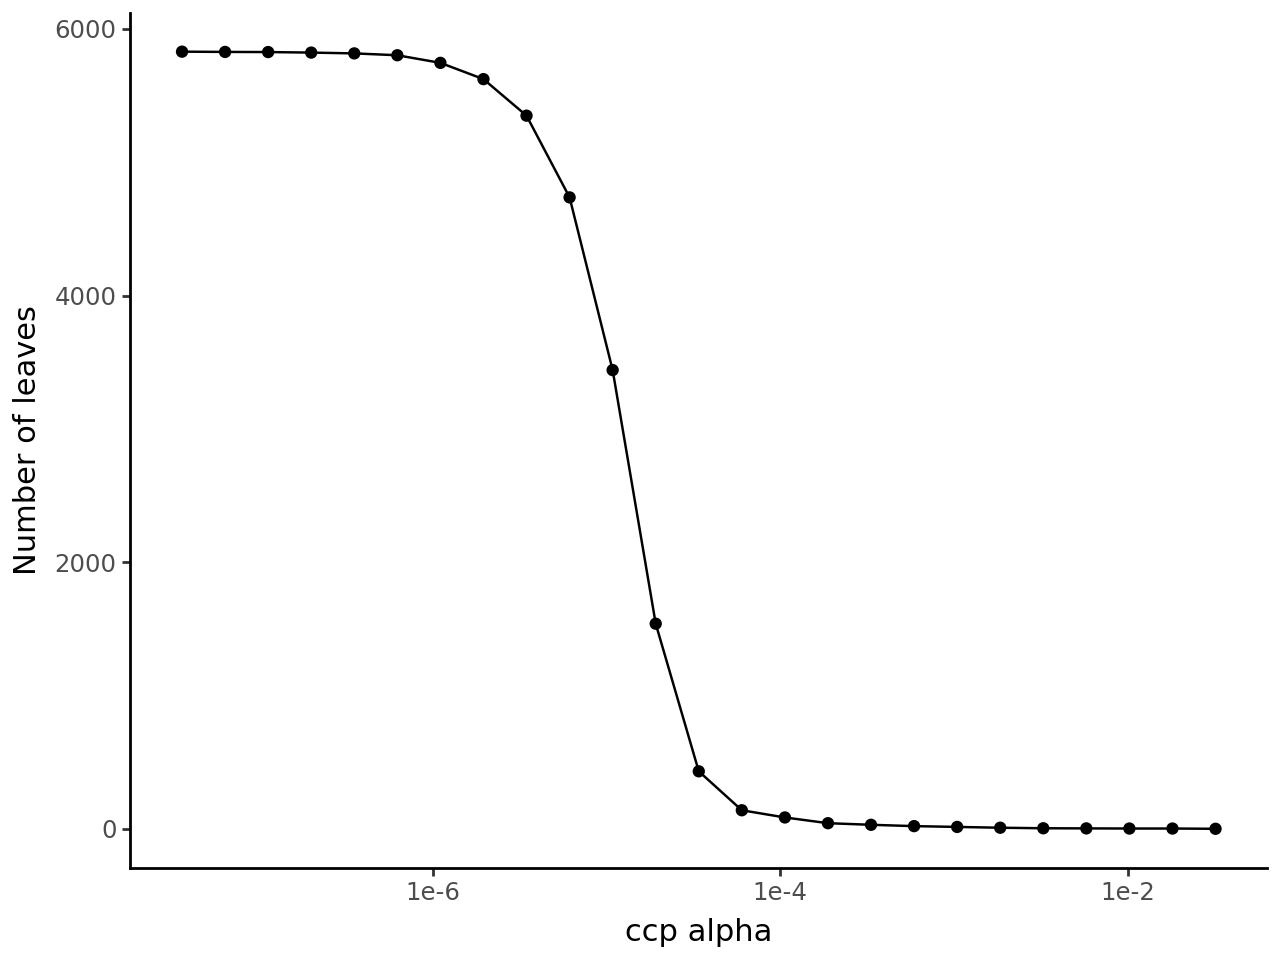

In [ ]:
# Plot number of leaves vs ccp_alpha
(
  ggplot(ccp_df, aes(x= 'ccp_alpha', y = 'n_leaves')) +
  geom_line() +
  geom_point() +
  labs(x = 'ccp alpha', y = 'Number of leaves') +
  scale_x_log10() +
  theme_classic()
)

In [ ]:
# Choose a ccp_alpha that gives a small, interpretable tree
# Look at the table above and pick one with ~5-15 leaves
optimal_ccp_alpha_c = ccp_df[ccp_df['n_leaves'] <= 15]
print(f"Chosen ccp_alpha: {optimal_ccp_alpha_c.iloc[0,0]}")
print(f"Expected number of leaves: {optimal_ccp_alpha_c.iloc[0,1]}")

Chosen ccp_alpha: 0.0010421332897412277
Expected number of leaves: 15


In [ ]:
pruned_tree_c = (min_samples_split = 20, min_samples_leaf=5, random_state=65, ccp_alpha=optimal_ccp_alpha_c.iloc[0,0])
pruned_tree_c.fit(X_train, y_train)

print(f"Number of leaves in pruned tree: {pruned_tree_c.get_n_leaves()}")
print(f"Depth of pruned tree: {pruned_tree_c.get_depth()}")

plt.figure(figsize=(20, 10))
plot_tree(pruned_tree_c, max_depth=3, feature_names=feature_cols, class_names= class_labels, fontsize = 7)
plt.title("Pruned Classification Tree")
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (<ipython-input-22-c1f6f39c9bba>, line 1)

Number of leaves in pruned tree: 15
Depth of pruned tree: 6


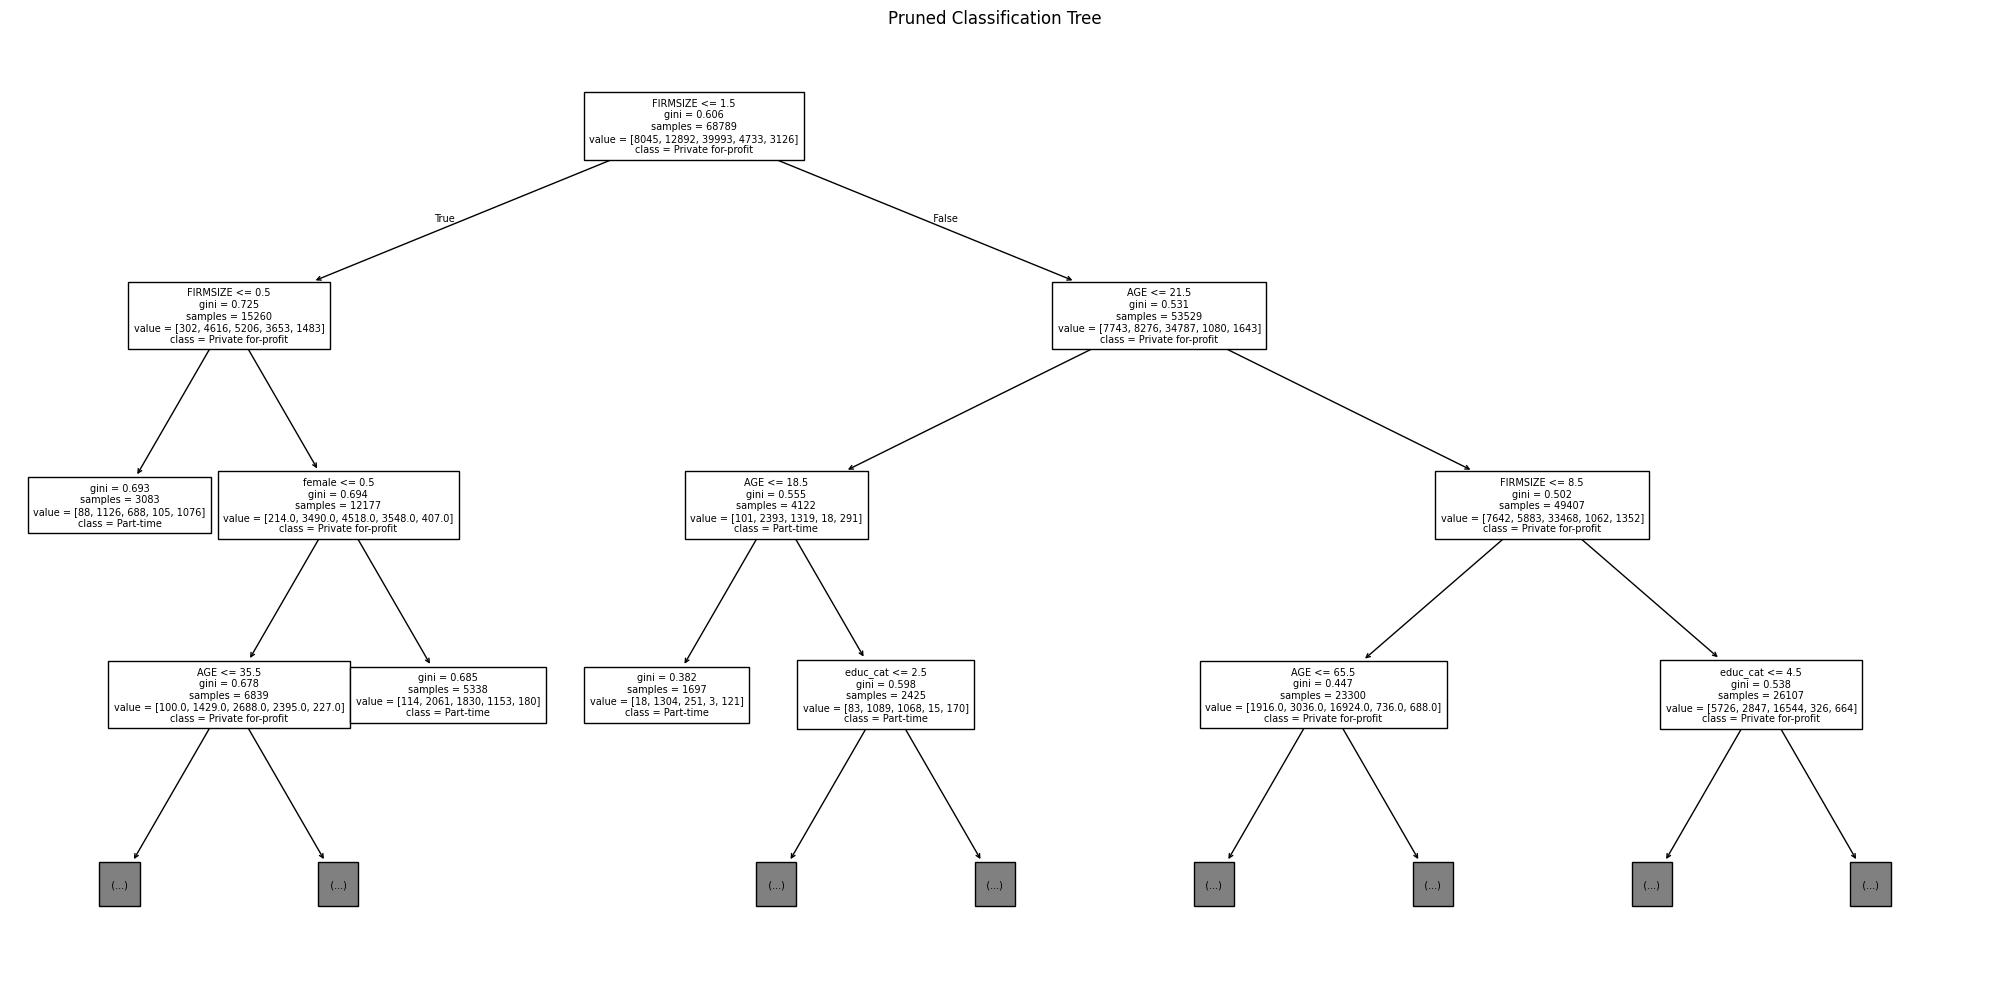

In [ ]:
pruned_tree_c = DecisionTreeClassifier(min_samples_split=20, min_samples_leaf=5, random_state=65, ccp_alpha=optimal_ccp_alpha_c.iloc[0,0])
pruned_tree_c.fit(X_train, y_train)

print(f"Number of leaves in pruned tree: {pruned_tree_c.get_n_leaves()}")
print(f"Depth of pruned tree: {pruned_tree_c.get_depth()}")

plt.figure(figsize=(20, 10))
plot_tree(pruned_tree_c, max_depth=3, feature_names=feature_cols, class_names= class_labels, fontsize = 7)
plt.title("Pruned Classification Tree")
plt.tight_layout()
plt.show()

Test accuracy (pruned tree): 0.6183982904243411
Test misclassification error (pruned tree): 0.38160170957565887


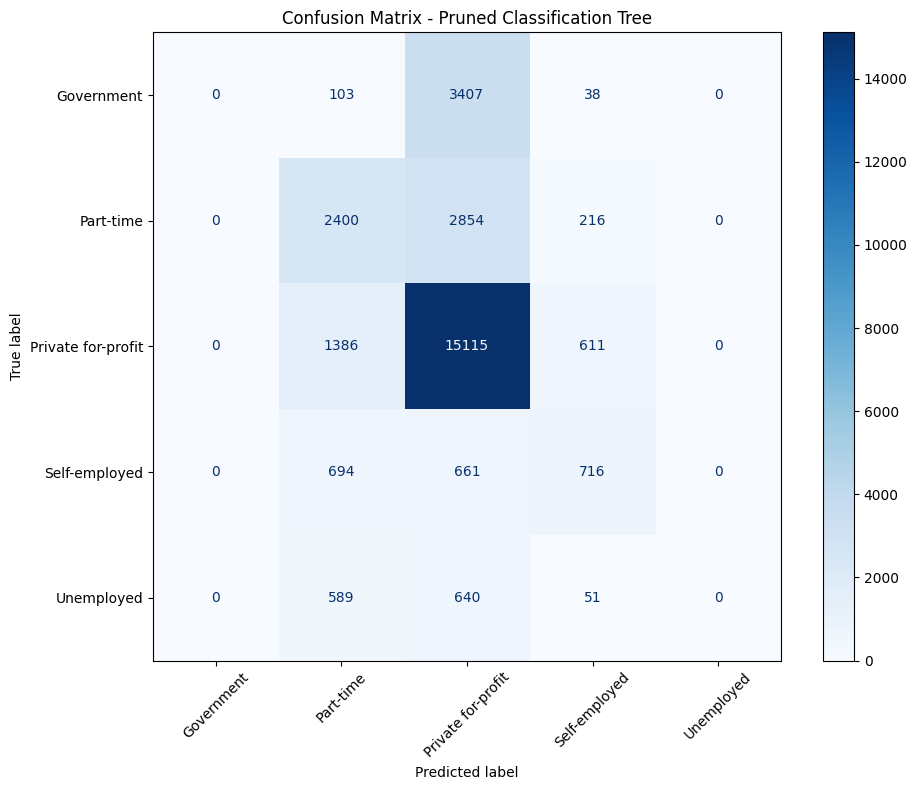

In [ ]:
y_pred_c = pruned_tree_c.predict(X_test)
test_acc_c = accuracy_score(y_test, y_pred_c)
test_error_c = 1 - test_acc_c
print(f"Test accuracy (pruned tree): {test_acc_c}")
print(f"Test misclassification error (pruned tree): {test_error_c}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_c)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Pruned Classification Tree")
plt.tight_layout()
plt.show()

In [ ]:
# Tune: try all combinations of max_features and min_samples_leaf

# oob is fitting on a subset with replacement (bootstrapping strat)
# will also test the model on unseend data (oob_score)
results = []
for mf in ['sqrt', 1/3, 0.5]:
    for msl in [1, 5, 10]:
        rf = RandomForestClassifier(
            max_features=mf, min_samples_leaf= msl, n_estimators = 200, oob_score=True, random_state=65
        )
        rf.fit(X_train, y_train)
        results.append({
            'max_features': mf, 'min_samples_leaf': msl,
            'oob_accuracy': rf.oob_score_
        })
        print(f'{rf.oob_score_}')

tune_df = pd.DataFrame(results).sort_values('oob_accuracy', ascending=False)
print(tune_df.to_string(index=False))

0.5669220369535827
0.6330372588640626
0.6354504353893791
0.5685502042477721
0.6334733751035776
0.6348689470700257
0.5730276643067932
0.6310020497463257
0.6342002355027694
max_features  min_samples_leaf  oob_accuracy
        sqrt                10      0.635450
    0.333333                10      0.634869
         0.5                10      0.634200
    0.333333                 5      0.633473
        sqrt                 5      0.633037
         0.5                 5      0.631002
         0.5                 1      0.573028
    0.333333                 1      0.568550
        sqrt                 1      0.566922


In [ ]:
# Fit the best model with n_estimators=500
best = tune_df.iloc[0]
print(f"Best parameters: max_features={best['max_features']}, min_samples_leaf={best['min_samples_leaf']}")

rf_class = RandomForestClassifier(
    max_features=best['max_features'], min_samples_leaf=best['min_samples_leaf'], n_estimators=500, oob_score=True, random_state=65
)
rf_class.fit(X_train, y_train)

y_pred_rf_c = rf_class.predict(X_test)
rf_test_acc_c = accuracy_score(y_test, y_pred_rf_c)

print(f"\nRandom Forest OOB accuracy: {rf_class.oob_score_}")
print(f"Random Forest OOB error: {1 - rf_class.oob_score_}")
print(f"Random Forest test accuracy: {rf_test_acc_c}")
print(f"Random Forest test error: {1 - rf_test_acc_c}")

Best parameters: max_features=sqrt, min_samples_leaf=10

Random Forest OOB accuracy: 0.6347381121981712
Random Forest OOB error: 0.3652618878018288
Random Forest test accuracy: 0.634340761846613
Random Forest test error: 0.36565923815338697


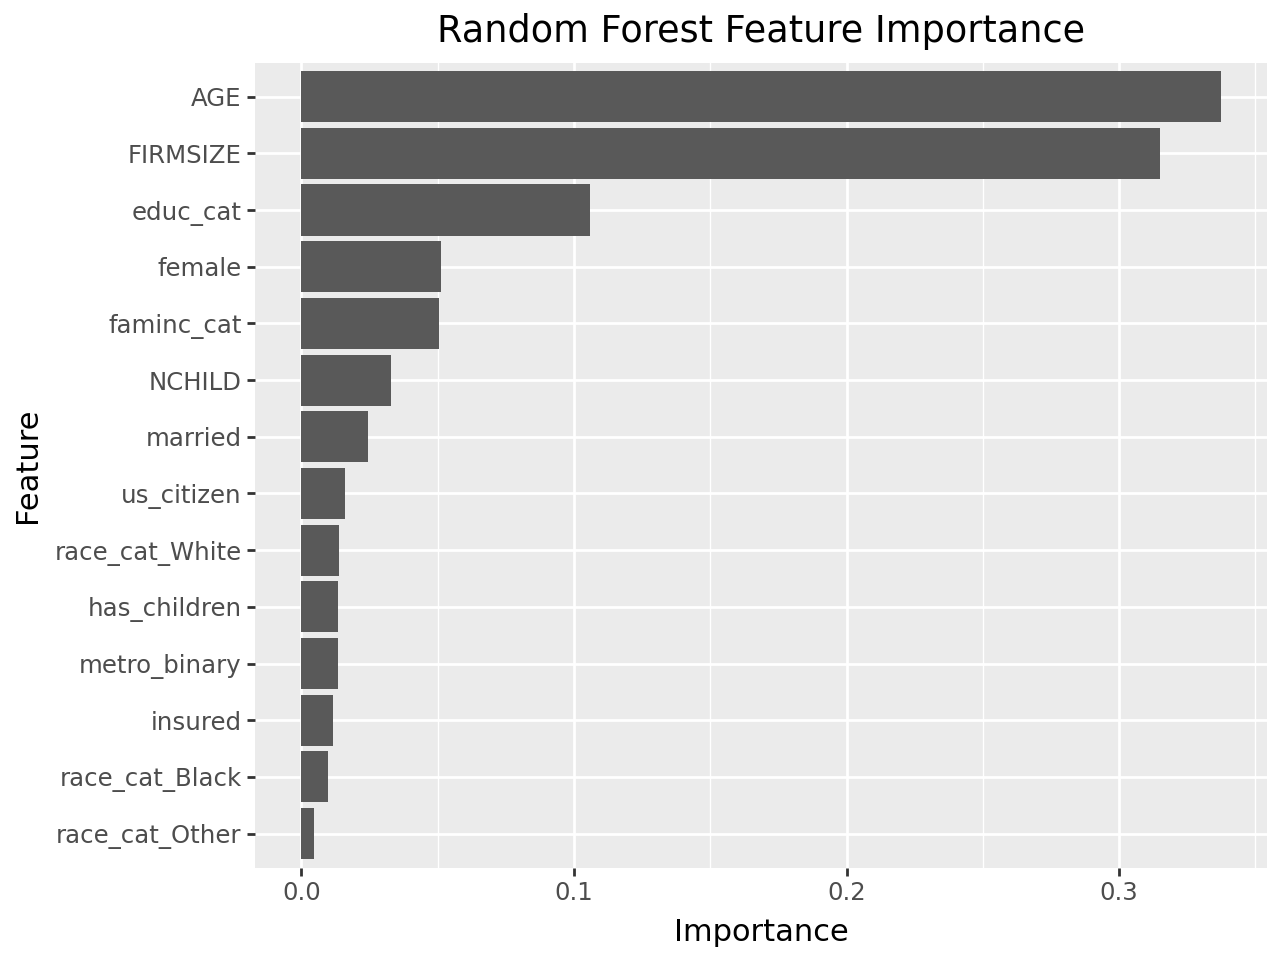

In [ ]:
rf_importances_c = rf_class.feature_importances_

imp_df_c = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_importances_c
}).sort_values('importance')
imp_df_c['feature'] = pd.Categorical(imp_df_c['feature'], categories=imp_df_c['feature'])

(
    ggplot(imp_df_c, aes(x='feature', y='importance')) +
    geom_col() +
    coord_flip() +
    labs(title="Random Forest Feature Importance", x="Feature", y="Importance")
)

In [ ]:
comparison_c = pd.DataFrame({
    'Model': ['Pruned Decision Tree', 'Random Forest'],
    'Test Accuracy': [pruned_tree_acc, rf_test_acc_c],
    'Test Misclassification Error': [1 - pruned_tree_acc, 1 - rf_test_acc_c]
})
print(comparison_c.to_string(index=False))

NameError: name 'pruned_tree_acc' is not defined

In [ ]:
comparison_c = pd.DataFrame({
    'Model': ['Pruned Decision Tree', 'Random Forest'],
    'Test Accuracy': [test_acc_c, rf_test_acc_c],
    'Test Misclassification Error': [1 - test_acc_c, 1 - rf_test_acc_c]
})
print(comparison_c.to_string(index=False))

               Model  Test Accuracy  Test Misclassification Error
Pruned Decision Tree       0.618398                      0.381602
       Random Forest       0.634341                      0.365659


In [ ]:
cps_reg = pd.get_dummies(cps, columns=['worker_cat'], drop_first=True)

# Build the regression feature list
worker_cat_cols = [c for c in cps_reg.columns if c.startswith('worker_cat_')]
reg_feature_cols = feature_cols + worker_cat_cols

X_reg = cps_reg[reg_feature_cols]
y_reg = cps_reg['INCWAGE']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, train_size = 0.7, random_state=65)

print(f"Training set size: {len(X_train_reg)}")
print(f"Testing set size: {len(X_test_reg)}")
print(f"\nINCWAGE in training set:")
print(f"  Mean: ${y_train_reg.mean()}")
print(f"  Std:  ${y_train_reg.std()}")
print(f"  Min:  ${y_train_reg.min()}")
print(f"  Max:  ${y_train_reg.max()}")

KeyError: "['race_cat_Black', 'race_cat_Other', 'race_cat_White'] not in index"

In [ ]:
cps_reg = pd.get_dummies(cps, columns=['worker_cat'], drop_first=True)

cps_reg.head()

# Build the regression feature list
worker_cat_cols = [c for c in cps_reg.columns if c.startswith('worker_cat_')]
reg_feature_cols = feature_cols + worker_cat_cols

X_reg = cps_reg[reg_feature_cols]
y_reg = cps_reg['INCWAGE']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, train_size = 0.7, random_state=65)

print(f"Training set size: {len(X_train_reg)}")
print(f"Testing set size: {len(X_test_reg)}")
print(f"\nINCWAGE in training set:")
print(f"  Mean: ${y_train_reg.mean()}")
print(f"  Std:  ${y_train_reg.std()}")
print(f"  Min:  ${y_train_reg.min()}")
print(f"  Max:  ${y_train_reg.max()}")

KeyError: "['race_cat_Black', 'race_cat_Other', 'race_cat_White'] not in index"

In [ ]:
cps_reg = pd.get_dummies(cps, columns=['worker_cat'], drop_first=True)

cps_reg.head()

,AGE,female,married,educ_cat,faminc_cat,metro_binary,race_cat,us_citizen,has_children,insured,...,IND,INCWAGE,FIRMSIZE,NCHILD,YEAR,STATEFIP,worker_cat_Part-time,worker_cat_Private for-profit,worker_cat_Self-employed,worker_cat_Unemployed
231802,63,0,1,2,3,0,White,1,1,1,...,270,61729,2,1,2024,23,False,False,True,False
231803,57,0,1,2,2,0,White,1,1,1,...,4972,43000,9,1,2024,23,False,True,False,False
231804,57,1,1,2,2,0,White,1,1,1,...,6380,25000,9,1,2024,23,True,False,False,False
231805,23,0,0,2,2,0,White,1,0,1,...,6170,20000,5,0,2024,23,False,True,False,False
231806,58,0,0,3,1,0,White,1,0,1,...,1870,80000,8,0,2024,23,False,True,False,False


In [ ]:
cps_reg = pd.get_dummies(cps, columns=['worker_cat', 'race_cat'], drop_first=True)

cps_reg.head()

,AGE,female,married,educ_cat,faminc_cat,metro_binary,us_citizen,has_children,insured,OCC,...,NCHILD,YEAR,STATEFIP,worker_cat_Part-time,worker_cat_Private for-profit,worker_cat_Self-employed,worker_cat_Unemployed,race_cat_Black,race_cat_Other,race_cat_White
231802,63,0,1,2,3,0,1,1,1,6130,...,1,2024,23,False,False,True,False,False,False,True
231803,57,0,1,2,2,0,1,1,1,4220,...,1,2024,23,False,True,False,False,False,False,True
231804,57,1,1,2,2,0,1,1,1,9005,...,1,2024,23,True,False,False,False,False,False,True
231805,23,0,0,2,2,0,1,0,1,9620,...,0,2024,23,False,True,False,False,False,False,True
231806,58,0,0,3,1,0,1,0,1,6355,...,0,2024,23,False,True,False,False,False,False,True


In [ ]:
cps_reg = pd.get_dummies(cps, columns=['worker_cat', 'race_cat'], drop_first=True)

cps_reg.head()

# Build the regression feature list
worker_cat_cols = [c for c in cps_reg.columns if c.startswith('worker_cat_')]
reg_feature_cols = feature_cols + worker_cat_cols

X_reg = cps_reg[reg_feature_cols]
y_reg = cps_reg['INCWAGE']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, train_size = 0.7, random_state=65)

print(f"Training set size: {len(X_train_reg)}")
print(f"Testing set size: {len(X_test_reg)}")
print(f"\nINCWAGE in training set:")
print(f"  Mean: ${y_train_reg.mean()}")
print(f"  Std:  ${y_train_reg.std()}")
print(f"  Min:  ${y_train_reg.min()}")
print(f"  Max:  ${y_train_reg.max()}")

Training set size: 68789
Testing set size: 29481

INCWAGE in training set:
  Mean: $64188.17158266583
  Std:  $86758.59021172916
  Min:  $0
  Max:  $2039999


Number of leaves in full tree: 5822
Depth of full tree: 31


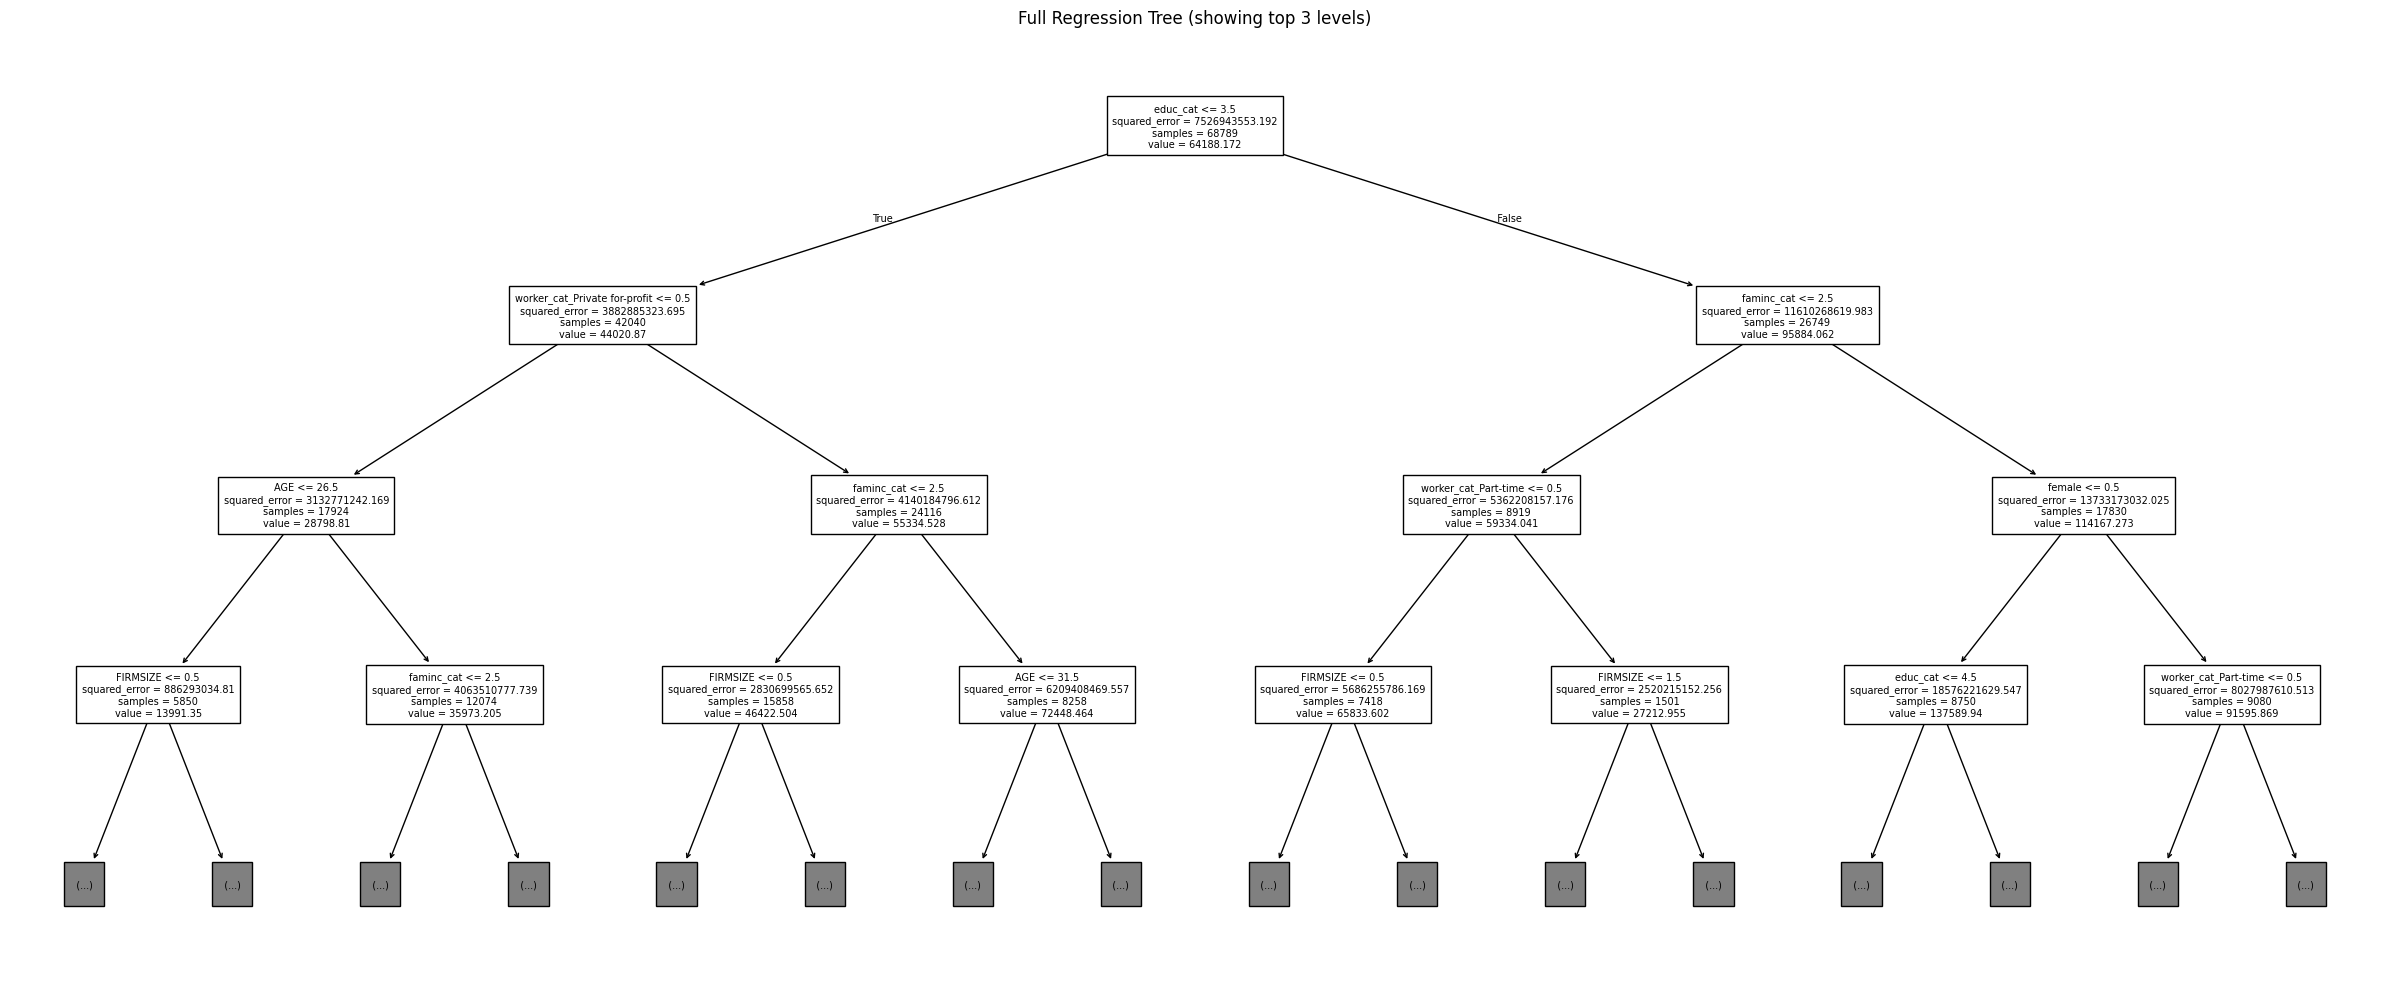

In [ ]:
full_tree_r = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, random_state=65)
full_tree_r.fit(X_train_reg, y_train_reg)

print(f"Number of leaves in full tree: {full_tree_r.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_r.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_r, max_depth=3, feature_names=reg_feature_cols, fontsize=7)
plt.title("Full Regression Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

In [ ]:
# Get the pruning path
path_r = full_tree_r.cost_complexity_pruning_path(X_train_reg, y_train_reg)
ccp_alphas_r = path_r.ccp_alphas
ccp_alphas_r_pos = ccp_alphas_r[ccp_alphas_r > 0]
# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
log_alphas_r = np.logspace(np.log10(ccp_alphas_r_pos.min()), np.log10(ccp_alphas_r_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves_r = []
for alpha in log_alphas_r:
    tree = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, ccp_alpha=alpha)
    tree.fit(X_train_reg, y_train_reg)
    n_leaves_r.append(tree.get_n_leaves())

ccp_df_r = pd.DataFrame({'ccp_alpha': log_alphas_r, 'n_leaves': n_leaves_r})
print(ccp_df_r)

       ccp_alpha  n_leaves
0   2.073530e+00      5821
1   4.681836e+00      5820
2   1.057114e+01      5819
3   2.386865e+01      5816
4   5.389317e+01      5807
5   1.216857e+02      5801
6   2.747549e+02      5780
7   6.203707e+02      5733
8   1.400739e+03      5669
9   3.162736e+03      5458
10  7.141161e+03      4927
11  1.612407e+04      4037
12  3.640663e+04      2861
13  8.220276e+04      1862
14  1.856061e+05      1188
15  4.190811e+05       744
16  9.462458e+05       335
17  2.136534e+06        82
18  4.824093e+06        39
19  1.089235e+07        24
20  2.459390e+07        14
21  5.553071e+07         6
22  1.253831e+08         4
23  2.831033e+08         2
24  6.392206e+08         1


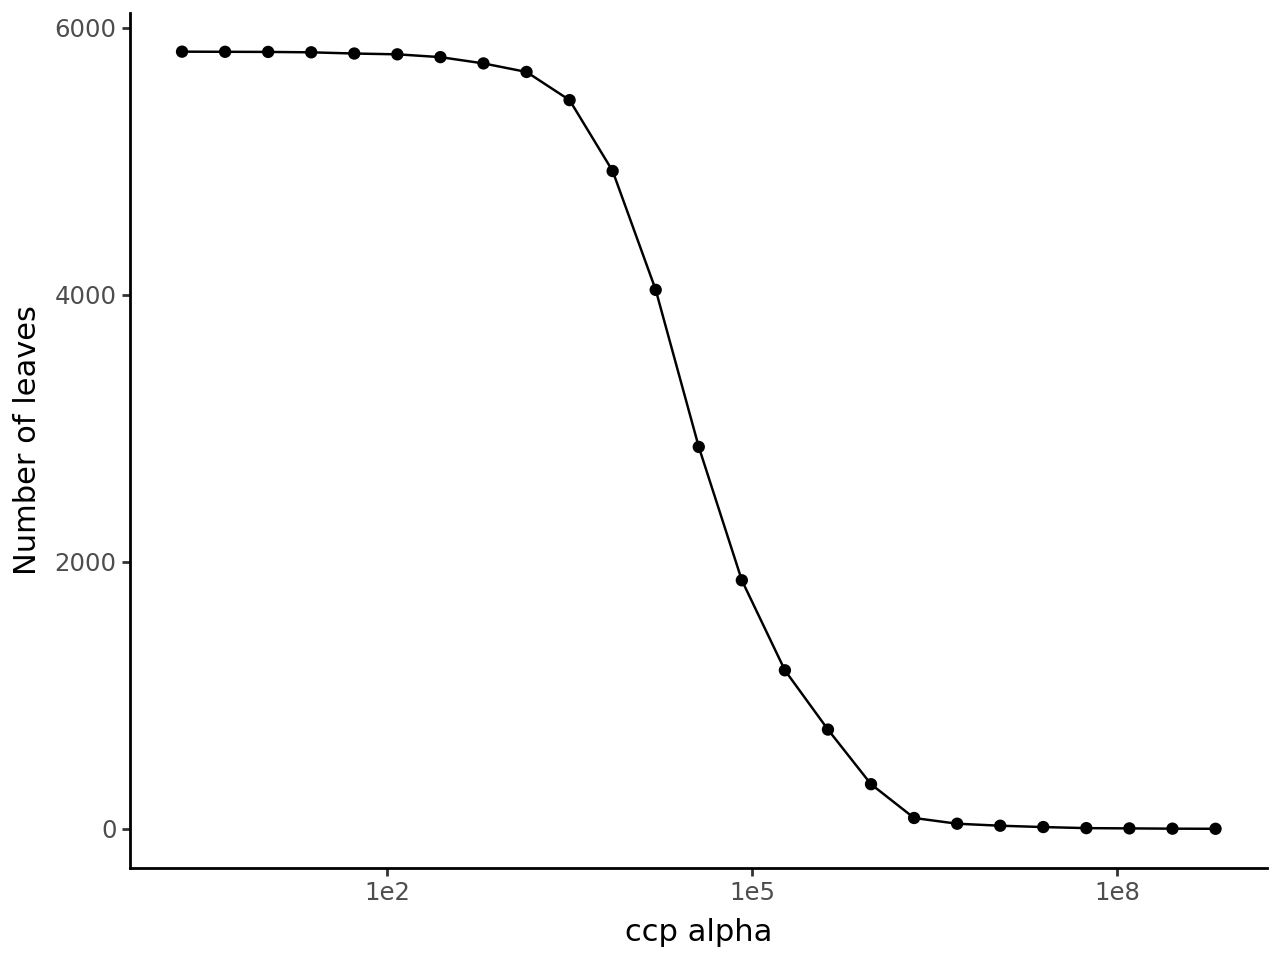

In [ ]:
# Plot number of leaves vs ccp_alpha
(
  ggplot(ccp_df_r, aes(x= 'ccp_alpha', y = 'n_leaves')) +
  geom_line() +
  geom_point() +
  labs(x = 'ccp alpha', y = 'Number of leaves') +
  scale_x_log10() +
  theme_classic()
)

In [ ]:
# Choose a ccp_alpha that gives a small, interpretable tree
optimal_ccp_alpha_r = ccp_df_r[ccp_df_r['n_leaves'] <= 15]
print(f"Chosen ccp_alpha: {optimal_ccp_alpha_r.iloc[0,0]}")
print(f"Expected number of leaves: {optimal_ccp_alpha_r.iloc[0,1]}")

Chosen ccp_alpha: 24593897.147016786
Expected number of leaves: 14


Number of leaves in full tree: 5822
Depth of full tree: 31


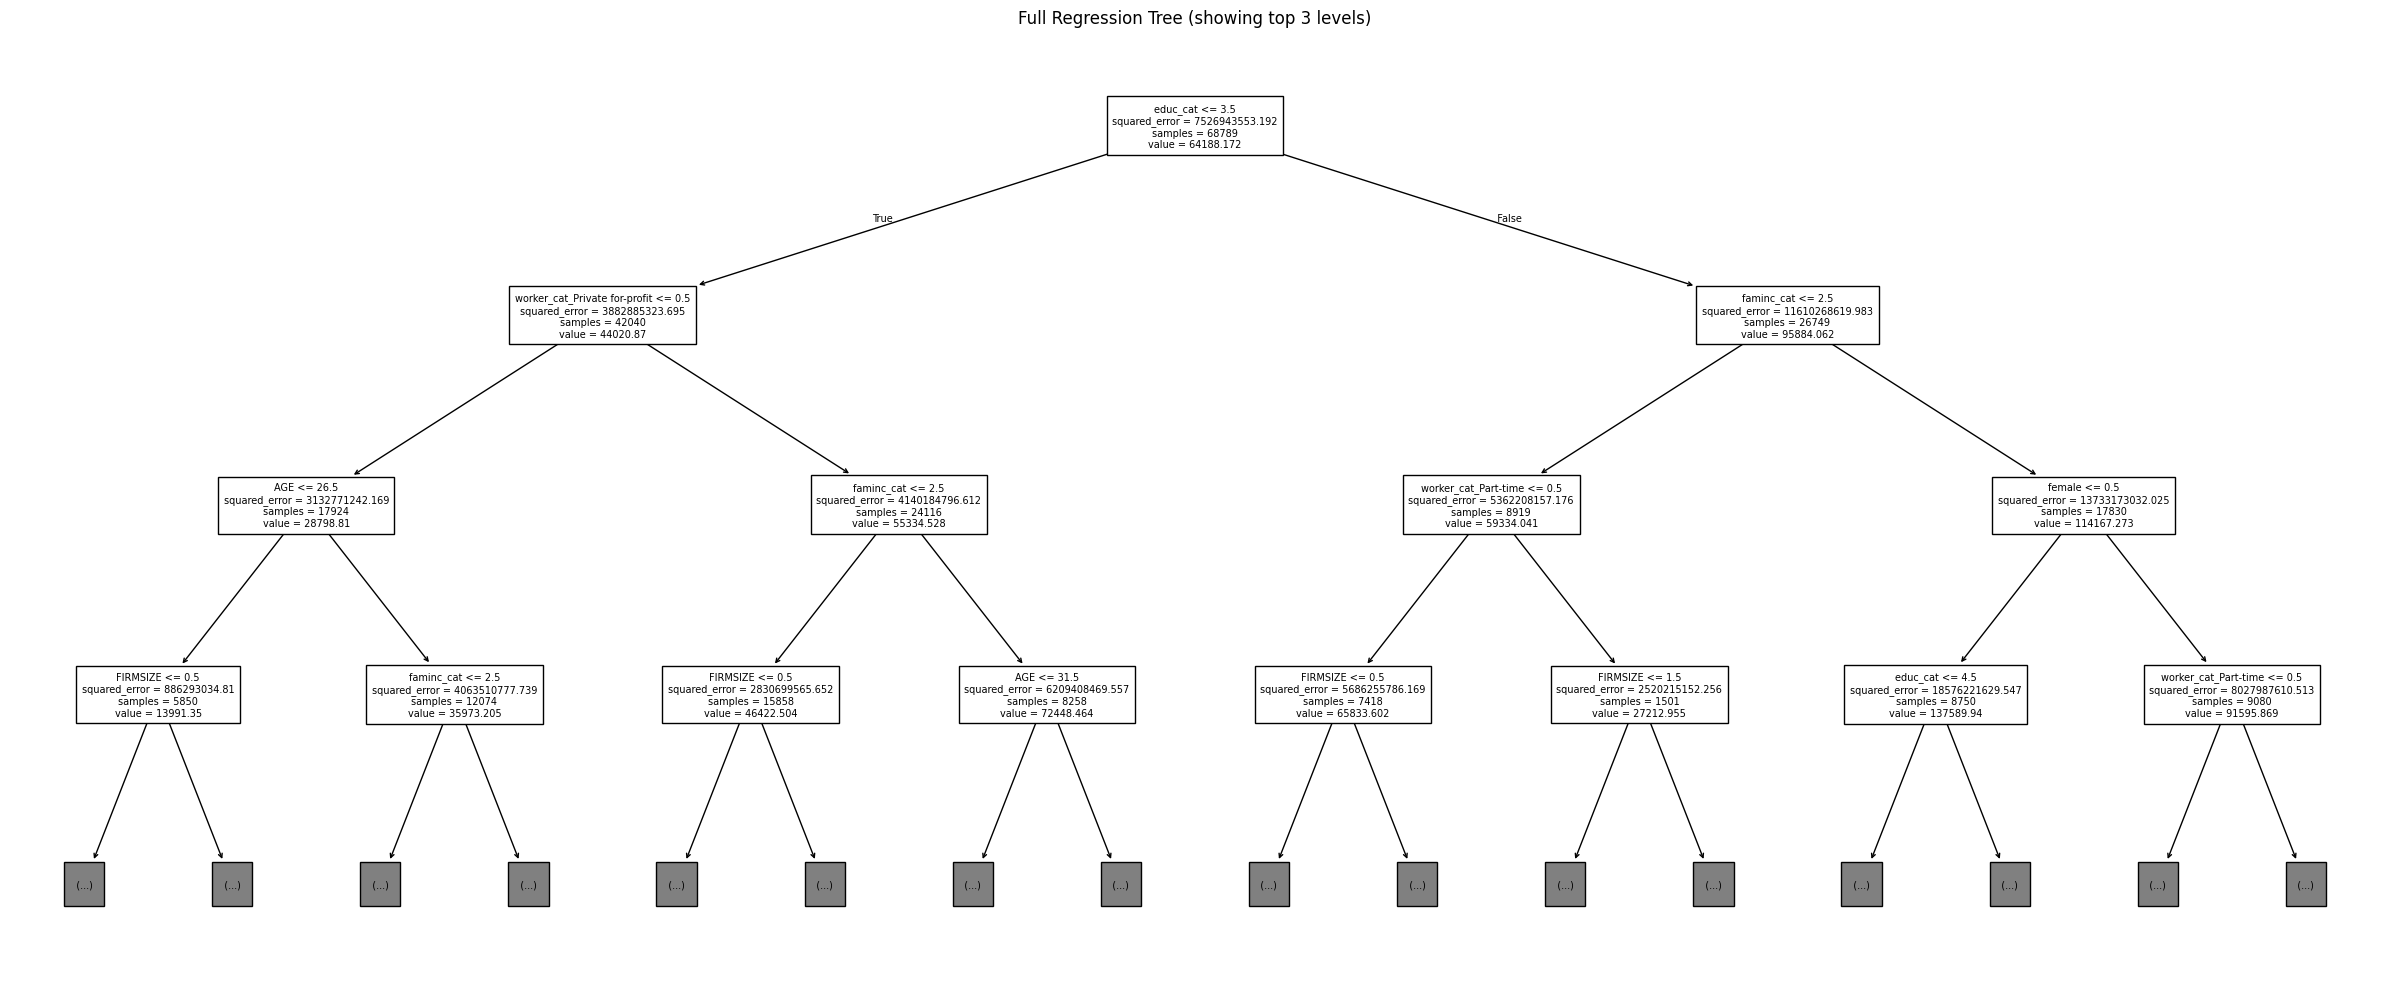

In [ ]:
class_labels_reg = sorted(y_class.unique())
full_tree_r = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, random_state=65)
full_tree_r.fit(X_train_reg, y_train_reg)

print(f"Number of leaves in full tree: {full_tree_r.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_r.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_r, max_depth=3, feature_names=reg_feature_cols, fontsize=7)
plt.title("Full Regression Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

Number of leaves in full tree: 5822
Depth of full tree: 31


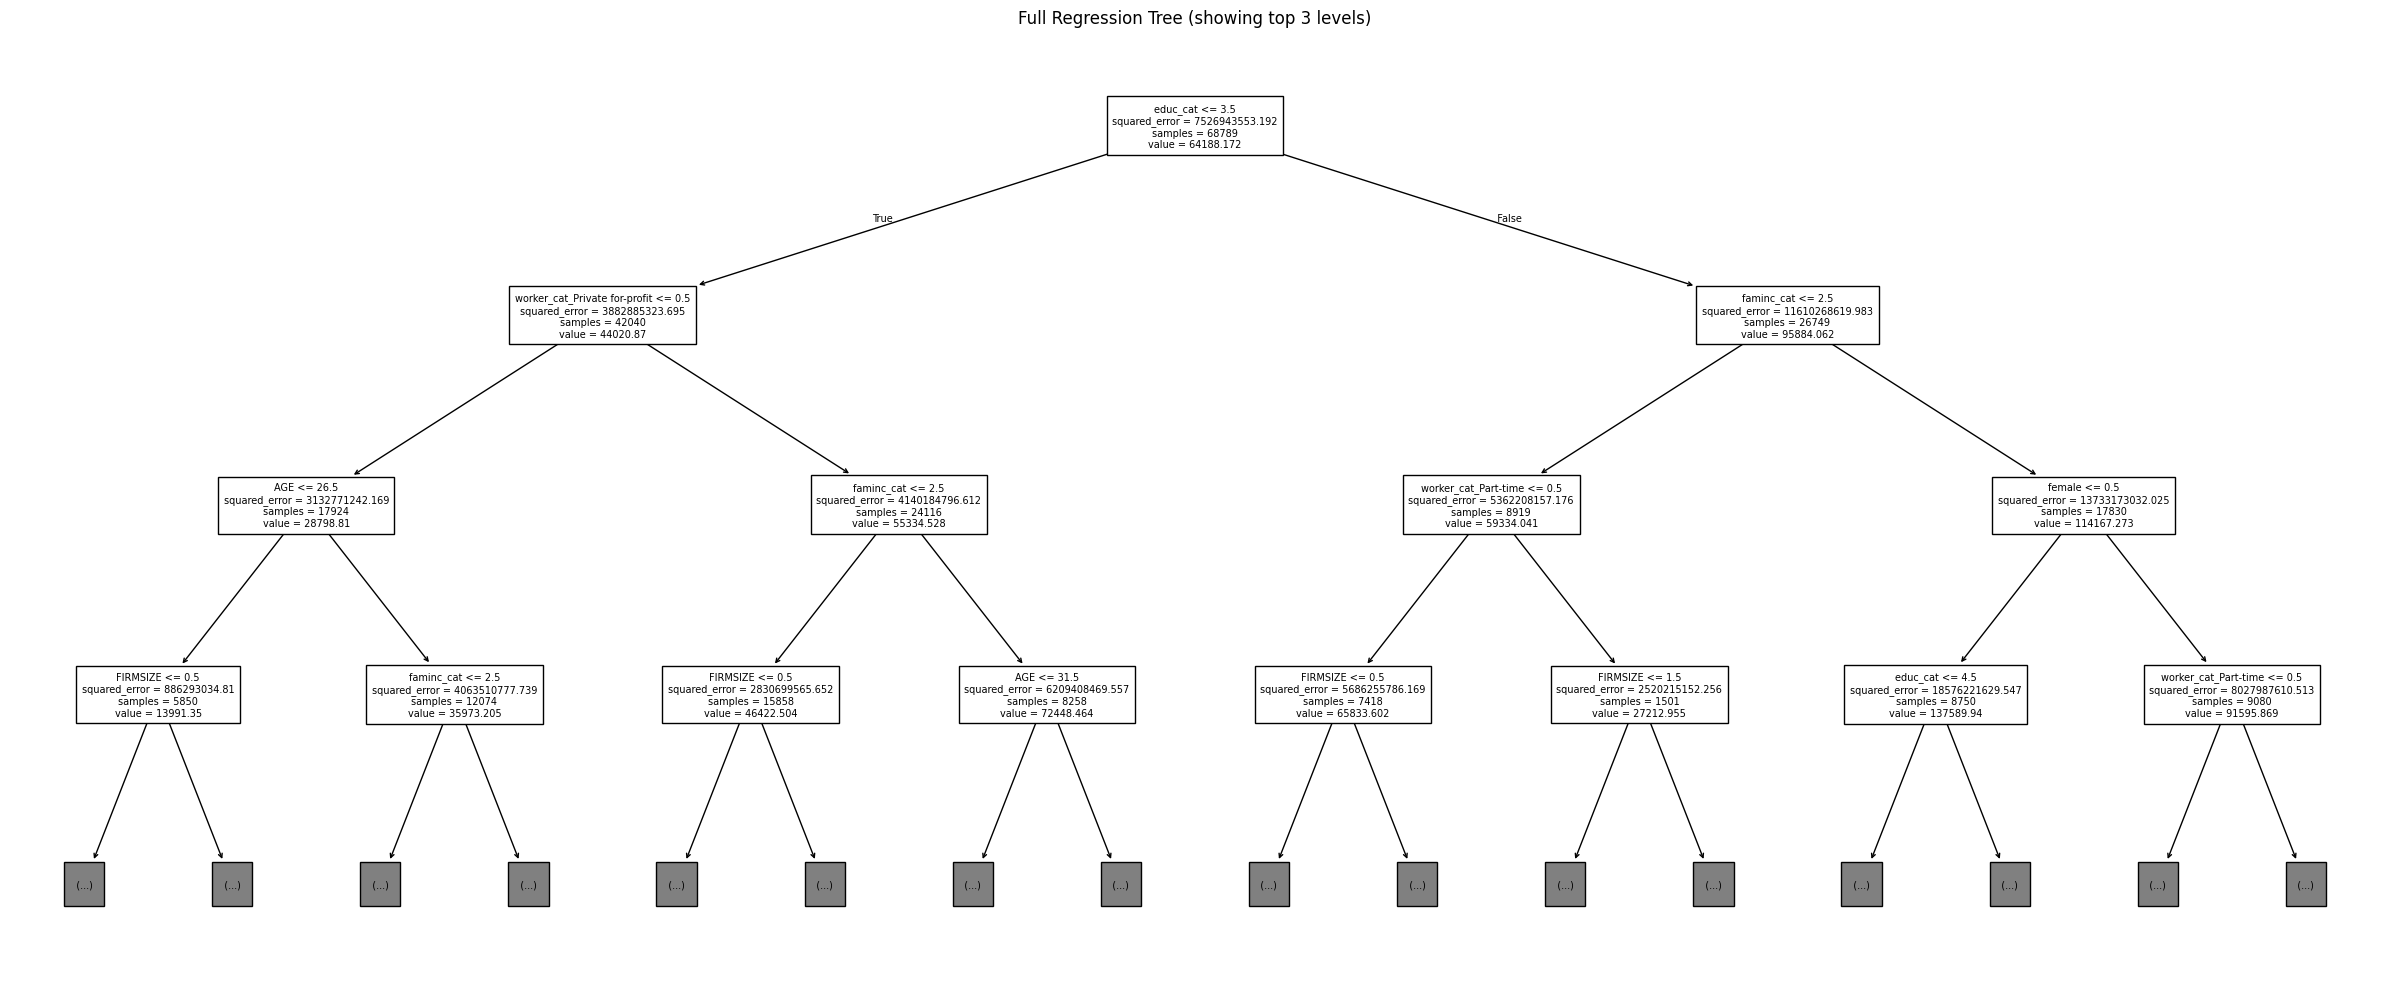

In [ ]:
class_labels_reg = sorted(y_class.unique())
full_tree_r = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, random_state=65)
full_tree_r.fit(X_train_reg, y_train_reg)

print(f"Number of leaves in full tree: {full_tree_r.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_r.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_r, max_depth=3, feature_names=reg_feature_cols, fontsize=7)
plt.title("Full Regression Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

Number of leaves in full tree: 5822
Depth of full tree: 31


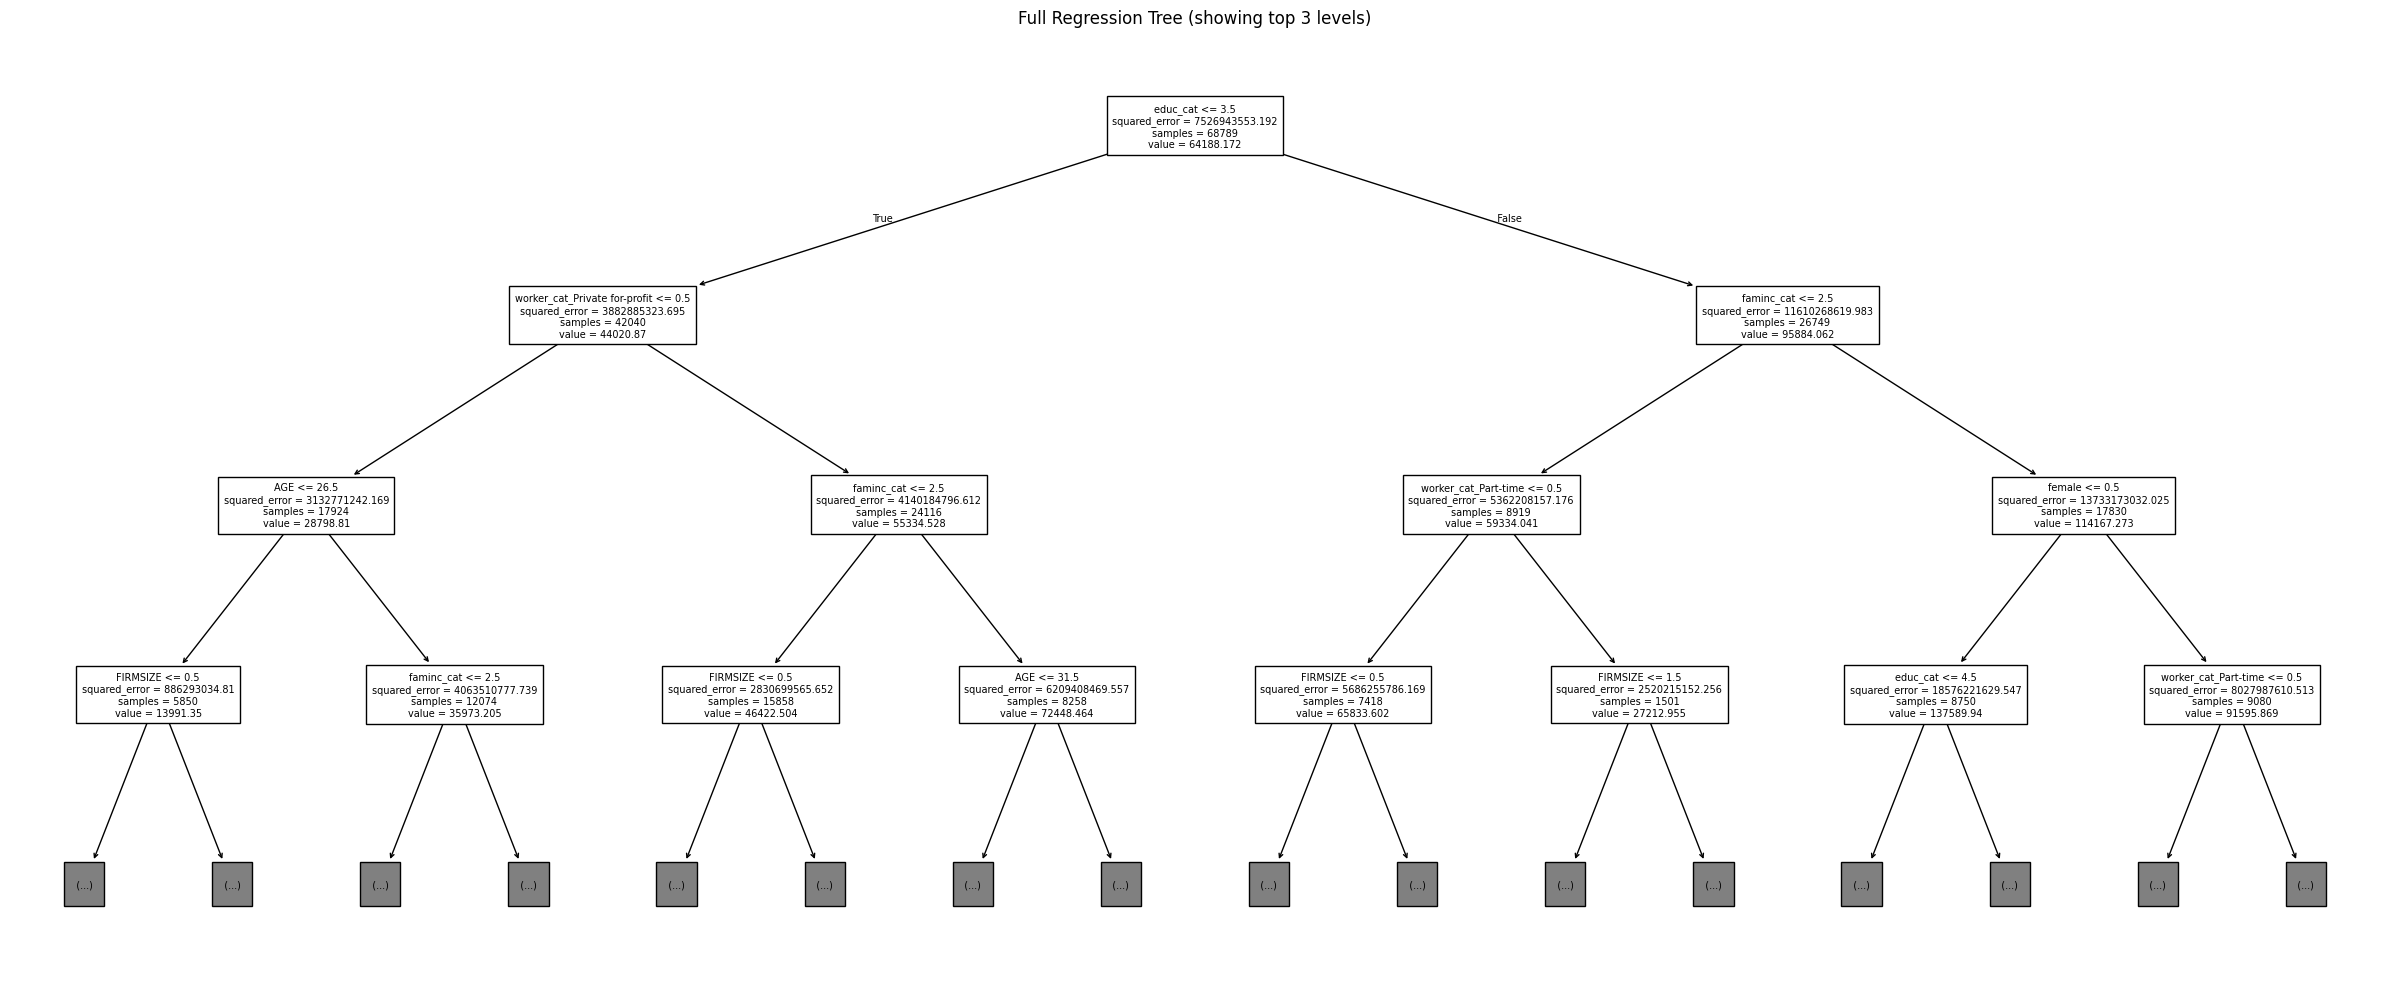

In [ ]:
class_labels_reg = sorted(y_class.unique())
full_tree_r = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, random_state=65)
full_tree_r.fit(X_train_reg, y_train_reg)

print(f"Number of leaves in full tree: {full_tree_r.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_r.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_r, max_depth=3, feature_names=reg_feature_cols, class_names =class_labels_reg, fontsize=7)
plt.title("Full Regression Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

Number of leaves in pruned tree: 14
Depth of pruned tree: 6

Test RMSE (pruned tree): $77971.10621695436
Test R-squared (pruned tree): 0.20408740191278407


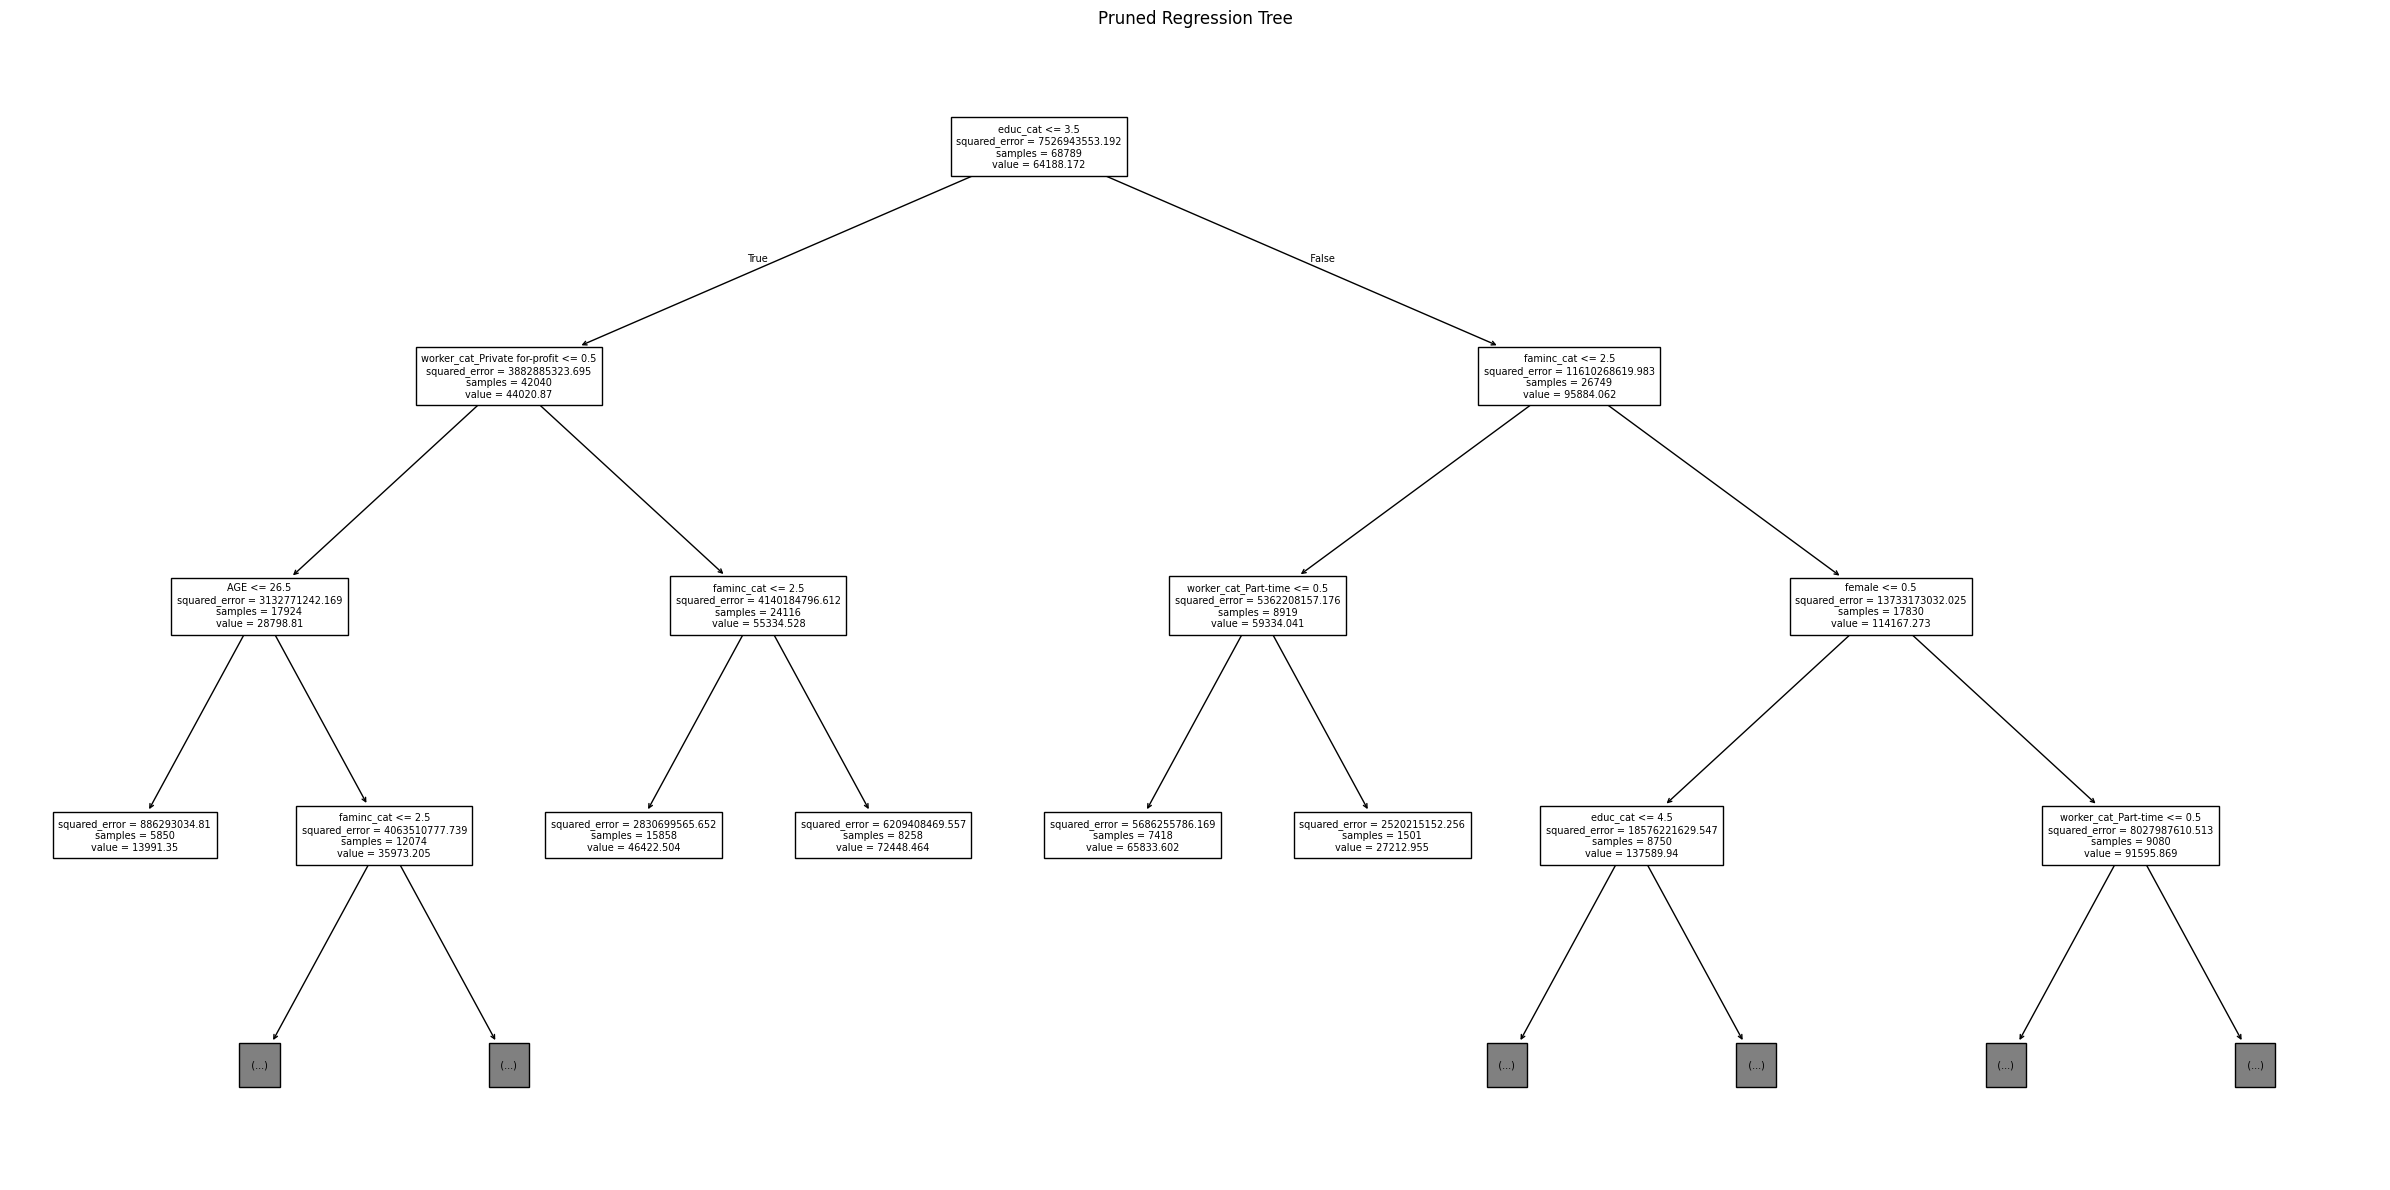

In [ ]:
pruned_tree_r = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, random_state=65, ccp_alpha=optimal_ccp_alpha_r.iloc[0,0])
pruned_tree_r.fit(X_train_reg, y_train_reg)

print(f"Number of leaves in pruned tree: {pruned_tree_r.get_n_leaves()}")
print(f"Depth of pruned tree: {pruned_tree_r.get_depth()}")

# Test performance
y_pred_r = pruned_tree_r.predict(X_test_reg)
test_rmse_tree = np.sqrt(mean_squared_error(y_test_reg, y_pred_r))
test_r2_tree = r2_score(y_test_reg, y_pred_r)
print(f"\nTest RMSE (pruned tree): ${test_rmse_tree}")
print(f"Test R-squared (pruned tree): {test_r2_tree}")

plt.figure(figsize=(24, 12))
plot_tree(pruned_tree_r, max_depth=3, class_names =class_labels_reg, feature_names=reg_feature_cols, fontsize=7)
plt.title("Pruned Regression Tree")
plt.tight_layout()
plt.show()

In [ ]:
# Tune over a small grid using OOB score
results_r = []
for mf in ['sqrt', 1/3, 0.5]:
    for msl in [1, 5, 10]:
        rf = RandomForestRegressor(
            max_features=mf, min_samples_leaf=msl, n_estimators=200, oob_score=True, random_state=65
        )
        rf.fit(X_train_reg, y_train_reg)
        results_r.append({
            'max_features': mf, 'min_samples_leaf': msl,
            'oob_r2': rf.oob_score_
        })

tune_df_r = pd.DataFrame(results_r).sort_values('oob_r2', ascending=False)
print(tune_df_r.to_string(index=False))

max_features  min_samples_leaf   oob_r2
        sqrt                10 0.250688
    0.333333                10 0.249883
        sqrt                 5 0.245313
         0.5                10 0.245084
    0.333333                 5 0.242149
         0.5                 5 0.234751
        sqrt                 1 0.095315
    0.333333                 1 0.095145
         0.5                 1 0.084141


In [ ]:
# Fit the best model with n_estimators=500
best_r = tune_df_r.iloc[0]
print(f"Best parameters: max_features={best_r['max_features']}, min_samples_leaf={best_r['min_samples_leaf']}")

rf_reg = RandomForestRegressor(
    max_features=best_r['max_features'], 
    min_samples_leaf=best_r['min_samples_leaf'],
    n_estimators=500, oob_score=True, random_state=65
)
rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf_r = rf_reg.predict(X_test_reg)
rf_test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_r))
rf_test_r2 = r2_score(y_test_reg, y_pred_rf_r)

print(f"\nRandom Forest OOB R-squared: {rf_reg.oob_score_}")
print(f"Random Forest test RMSE: ${rf_test_rmse}")
print(f"Random Forest test R-squared: {rf_test_r2}")

Best parameters: max_features=sqrt, min_samples_leaf=10

Random Forest OOB R-squared: 0.2510477537622682
Random Forest test RMSE: $75052.43584193056
Random Forest test R-squared: 0.2625585050834852


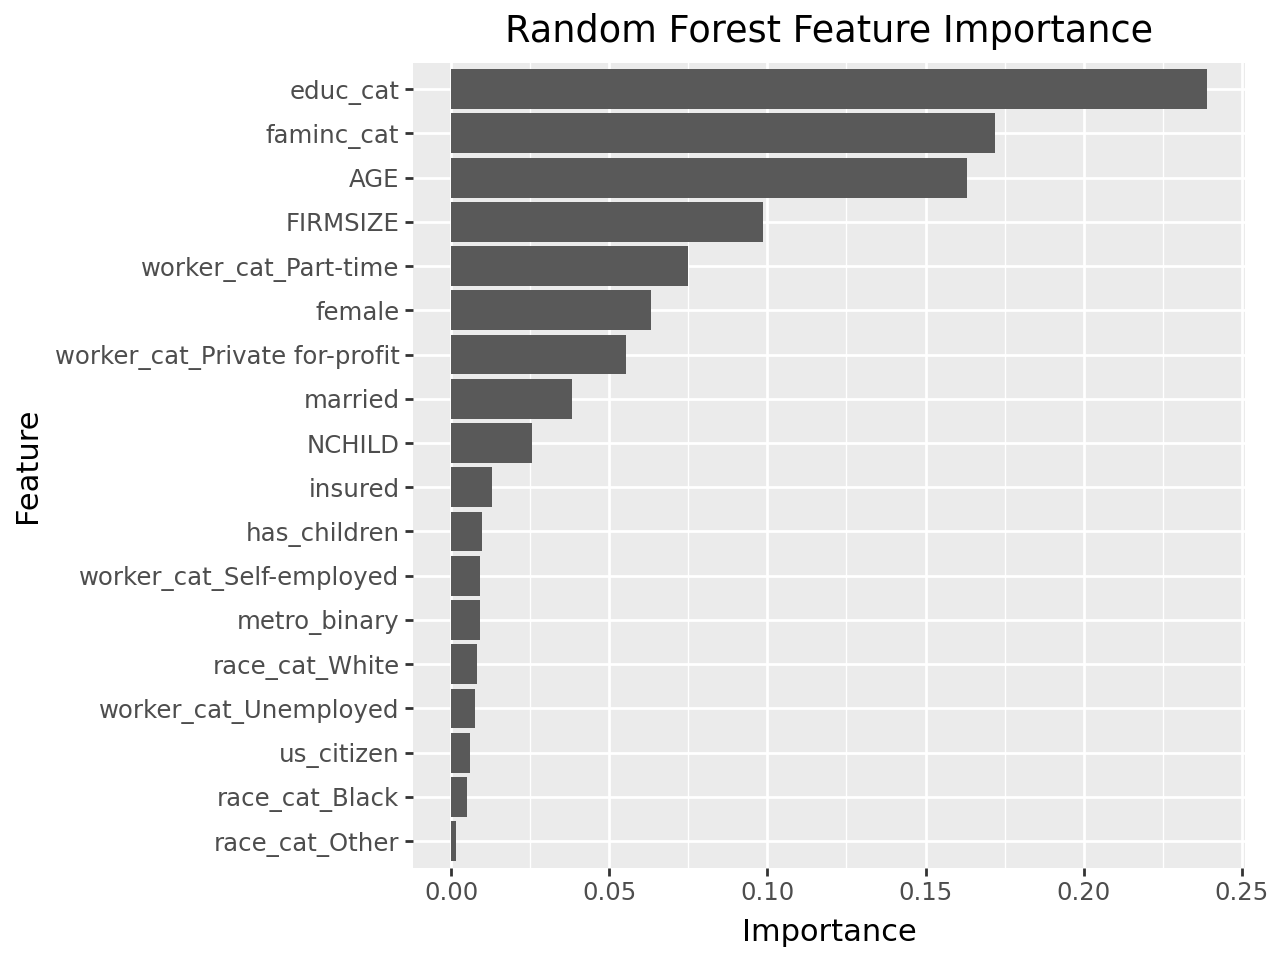

In [ ]:
rf_importances_r = rf_reg.feature_importances_

imp_df_r = pd.DataFrame({
    'feature': reg_feature_cols,
    'importance': rf_importances_r
}).sort_values('importance')
imp_df_r['feature'] = pd.Categorical(imp_df_r['feature'], categories=imp_df_r['feature'])

(
     ggplot(imp_df_r, aes(x='feature', y='importance')) +
    geom_col() +
    coord_flip() +
    labs(title="Random Forest Feature Importance", x="Feature", y="Importance")
)

In [ ]:
comparison_r = pd.DataFrame({
    'Model': ['Pruned Regression Tree', 'Random Forest'],
    'Test RMSE': [test_rmse_tree, rf_test_rmse],
    'Test R-squared': [test_r2_tree, rf_test_r2]
})
print(comparison_r.to_string(index=False))

                 Model    Test RMSE  Test R-squared
Pruned Regression Tree 77971.106217        0.204087
         Random Forest 75052.435842        0.262559


In [ ]:
cps_reg = pd.get_dummies(cps_encoded, columns=['worker_cat'], drop_first=True)

cps_reg.head()

# Build the regression feature list
worker_cat_cols = [c for c in cps_reg.columns if c.startswith('worker_cat_')]
reg_feature_cols = feature_cols + worker_cat_cols

X_reg = cps_reg[reg_feature_cols]
y_reg = cps_reg['INCWAGE']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, train_size = 0.7, random_state=65)

print(f"Training set size: {len(X_train_reg)}")
print(f"Testing set size: {len(X_test_reg)}")
print(f"\nINCWAGE in training set:")
print(f"  Mean: ${y_train_reg.mean()}")
print(f"  Std:  ${y_train_reg.std()}")
print(f"  Min:  ${y_train_reg.min()}")
print(f"  Max:  ${y_train_reg.max()}")

Training set size: 68789
Testing set size: 29481

INCWAGE in training set:
  Mean: $64188.17158266583
  Std:  $86758.59021172916
  Min:  $0
  Max:  $2039999


Number of leaves in full tree: 5822
Depth of full tree: 31


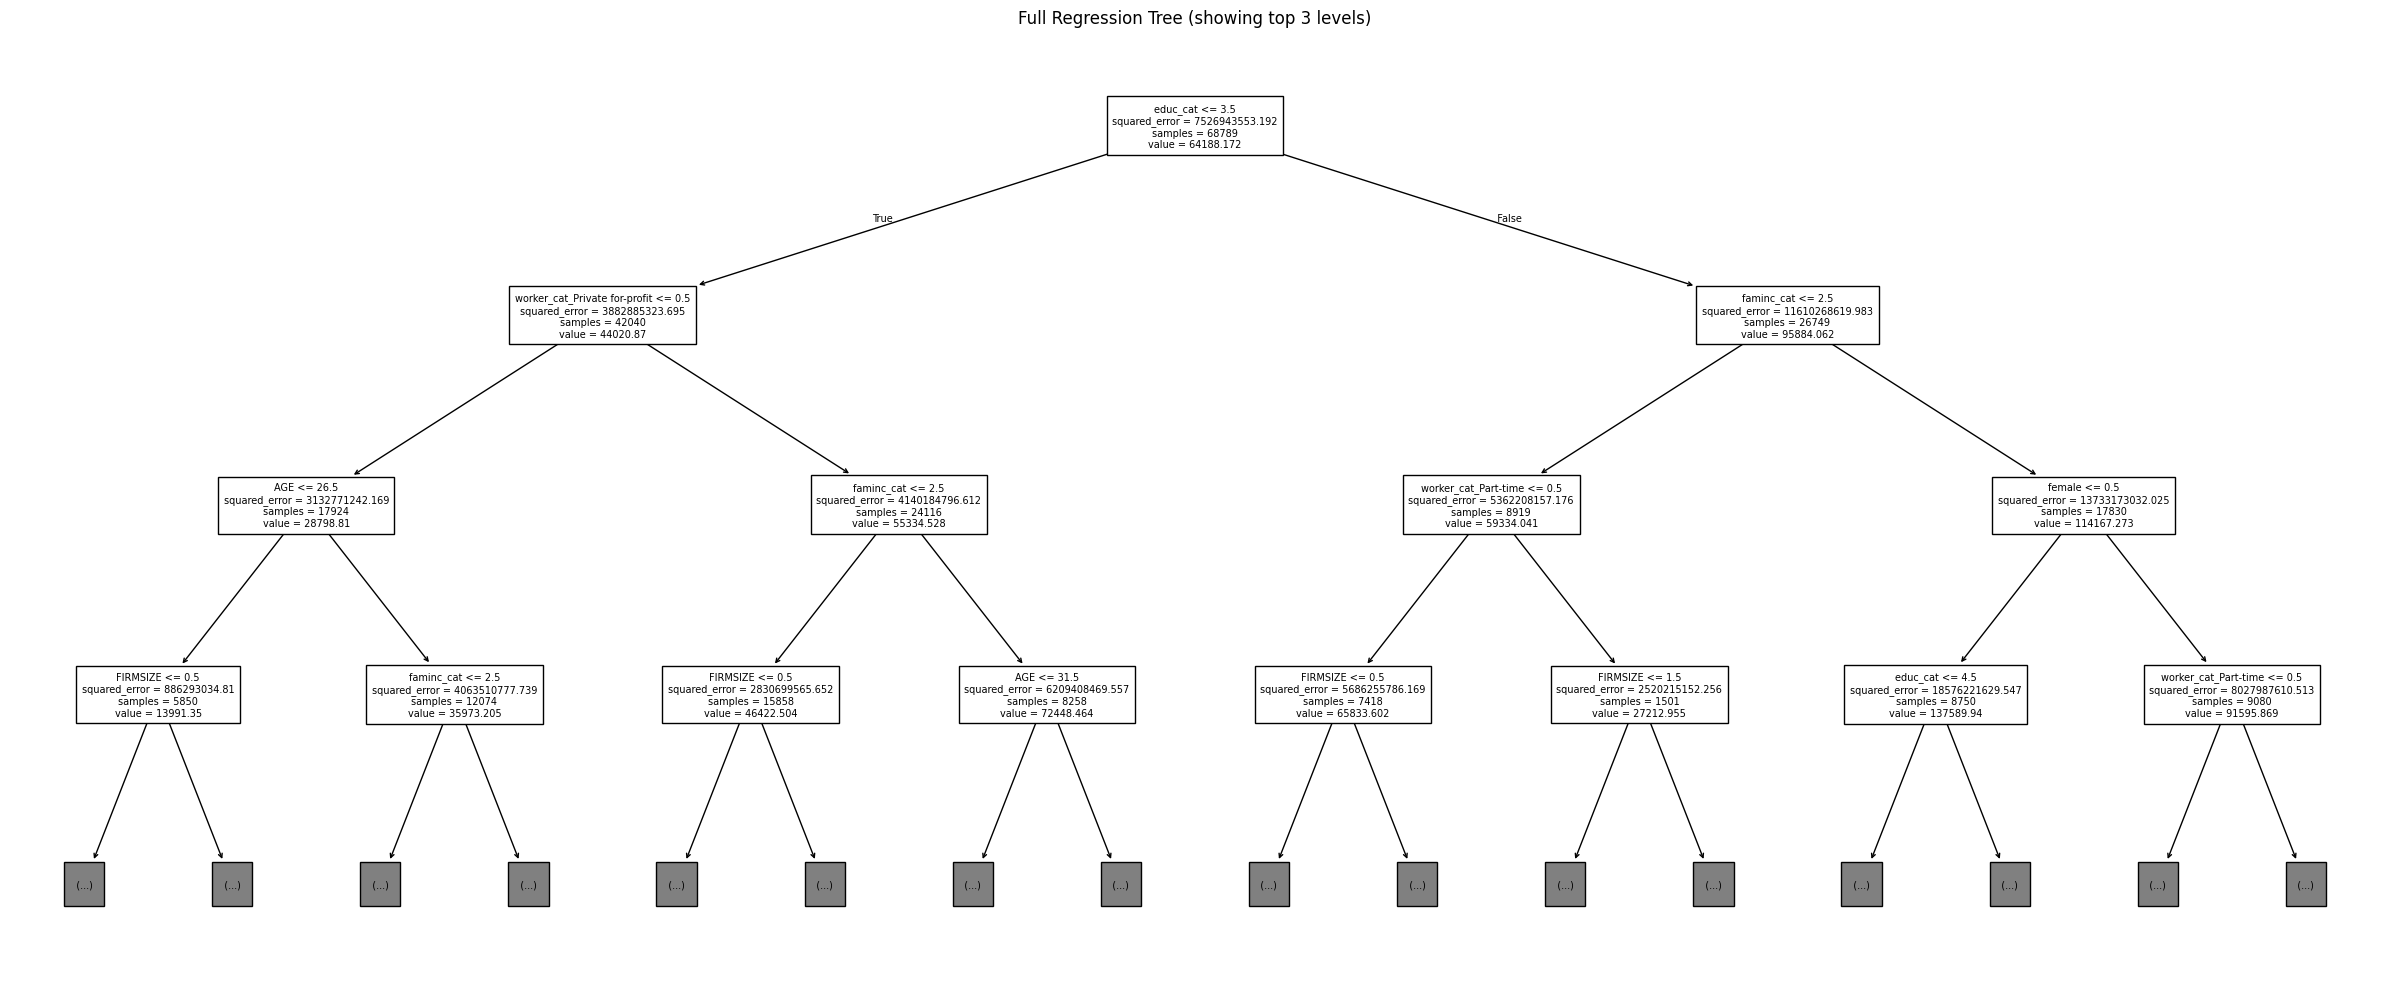

In [ ]:
class_labels_reg = sorted(y_class.unique())
full_tree_r = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, random_state=65)
full_tree_r.fit(X_train_reg, y_train_reg)

print(f"Number of leaves in full tree: {full_tree_r.get_n_leaves()}")
print(f"Depth of full tree: {full_tree_r.get_depth()}")

plt.figure(figsize=(24, 10))
plot_tree(full_tree_r, max_depth=3, feature_names=reg_feature_cols, class_names =class_labels_reg, fontsize=7)
plt.title("Full Regression Tree (showing top 3 levels)")
plt.tight_layout()
plt.show()

In [ ]:
# Get the pruning path
path_r = full_tree_r.cost_complexity_pruning_path(X_train_reg, y_train_reg)
ccp_alphas_r = path_r.ccp_alphas
ccp_alphas_r_pos = ccp_alphas_r[ccp_alphas_r > 0]
# Subsample ~25 log-spaced alpha values (fitting a tree for every alpha is too slow)
log_alphas_r = np.logspace(np.log10(ccp_alphas_r_pos.min()), np.log10(ccp_alphas_r_pos.max()), num=25)

# Compute number of leaves for each sampled alpha
n_leaves_r = []
for alpha in log_alphas_r:
    tree = DecisionTreeRegressor(min_samples_split=20, min_samples_leaf=5, ccp_alpha=alpha)
    tree.fit(X_train_reg, y_train_reg)
    n_leaves_r.append(tree.get_n_leaves())

ccp_df_r = pd.DataFrame({'ccp_alpha': log_alphas_r, 'n_leaves': n_leaves_r})
print(ccp_df_r)

       ccp_alpha  n_leaves
0   2.073530e+00      5821
1   4.681836e+00      5820
2   1.057114e+01      5819
3   2.386865e+01      5816
4   5.389317e+01      5807
5   1.216857e+02      5801
6   2.747549e+02      5780
7   6.203707e+02      5733
8   1.400739e+03      5669
9   3.162736e+03      5458
10  7.141161e+03      4927
11  1.612407e+04      4037
12  3.640663e+04      2861
13  8.220276e+04      1862
14  1.856061e+05      1188
15  4.190811e+05       744
16  9.462458e+05       335
17  2.136534e+06        82
18  4.824093e+06        39
19  1.089235e+07        24
20  2.459390e+07        14
21  5.553071e+07         6
22  1.253831e+08         4
23  2.831033e+08         2
24  6.392206e+08         1


In [ ]:
# Fit the best model with n_estimators=500
best_r = tune_df_r.iloc[0]
print(f"Best parameters: max_features={best_r['max_features']}, min_samples_leaf={best_r['min_samples_leaf']}")

rf_reg = RandomForestRegressor(
    max_features=best_r['max_features'], 
    min_samples_leaf=best_r['min_samples_leaf'],
    n_estimators=500, oob_score=True, random_state=65
)
rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf_r = rf_reg.predict(X_test_reg)
rf_test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_r))
rf_test_r2 = r2_score(y_test_reg, y_pred_rf_r)

print(f"\nRandom Forest OOB R-squared: {rf_reg.oob_score_}")
print(f"Random Forest test RMSE: ${rf_test_rmse}")
print(f"Random Forest test R-squared: {rf_test_r2}")

Best parameters: max_features=sqrt, min_samples_leaf=10

Random Forest OOB R-squared: 0.2510477537622682
Random Forest test RMSE: $75052.43584193056
Random Forest test R-squared: 0.2625585050834852


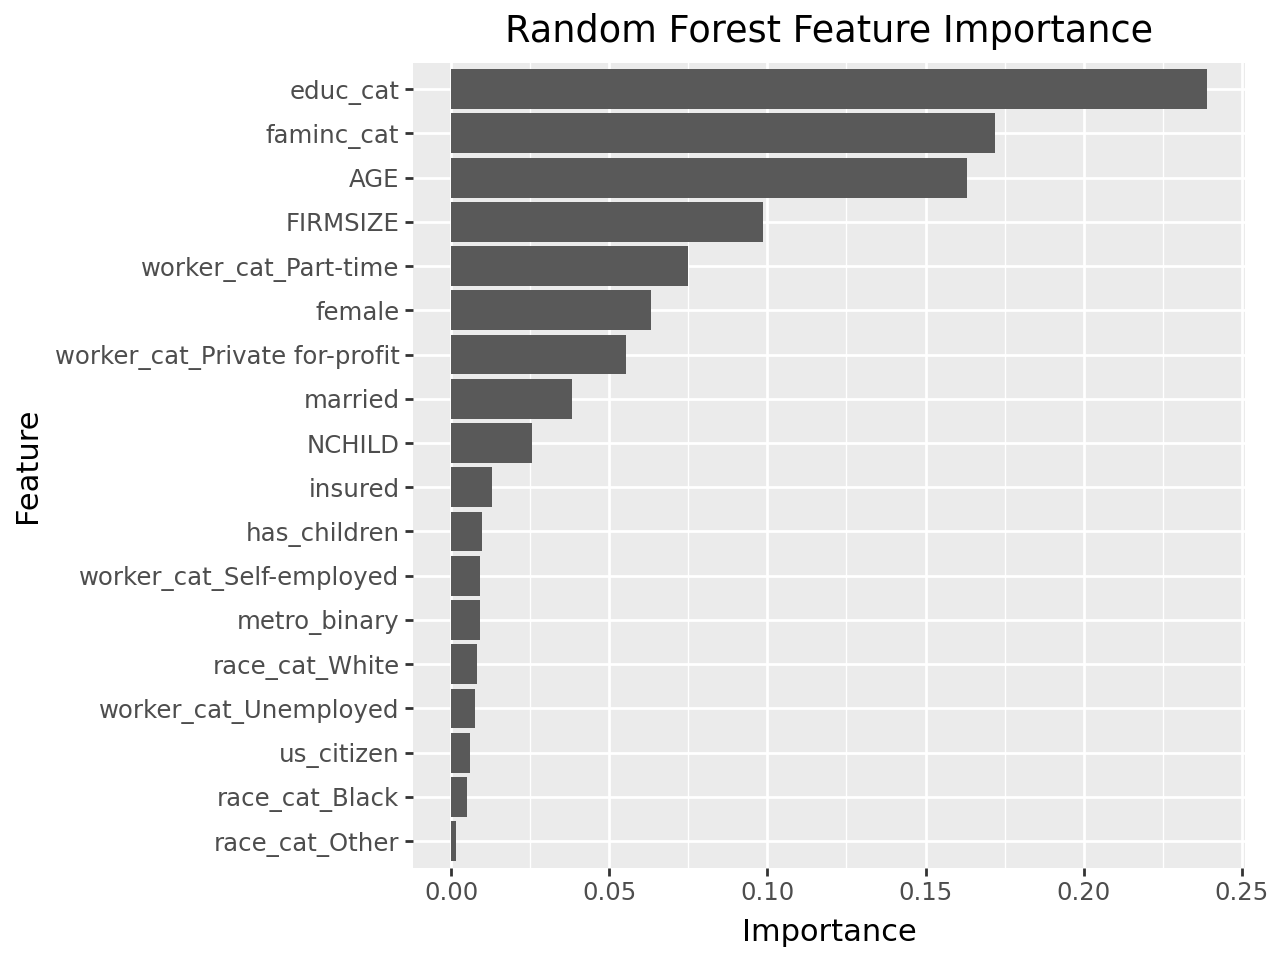

In [ ]:
rf_importances_r = rf_reg.feature_importances_

imp_df_r = pd.DataFrame({
    'feature': reg_feature_cols,
    'importance': rf_importances_r
}).sort_values('importance')
imp_df_r['feature'] = pd.Categorical(imp_df_r['feature'], categories=imp_df_r['feature'])

(
     ggplot(imp_df_r, aes(x='feature', y='importance')) +
    geom_col() +
    coord_flip() +
    labs(title="Random Forest Feature Importance", x="Feature", y="Importance")
)